In [ ]:
!pip install astroquery scikit-learn emcee corner treecorr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.9 MB/s eta 0:00:00


# Inverse Transform Sampling

If we sample $r$ from the uniform random distribution $\mathscr{U}(0, 1)$, then we may get the target probabilty distribution $p(x)$,

$$
r = \int_{x_{\min}}^{x}p(x')dx'
$$

The RHS in the above equation is the CDF of p(x). If the integral can be done analytically, we can solve for $x$ to get a relation such that we can choose $x$ from $r$, such that we get our target distribution $p(x)$.


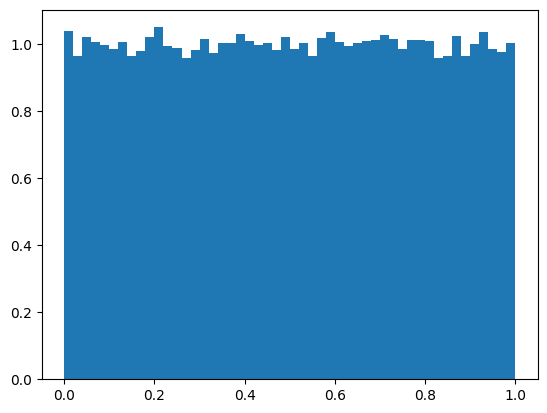

In [ ]:

# plotting the distribution of uniform probability distribution

import numpy as np
import matplotlib.pyplot as plt

r = np.random.uniform(low=0.0, high=1.0, size=100000)
# print(r)
plt.hist(r, bins=50, density=True)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.show()

#### Example 1: Getting a scaled uniform distribution

If we want a uniform probability distribution $\mathscr{U}(a, b)$, then, the distribution which follows this is,

\begin{equation*}
    p(x) = \left\{
    \begin{array}{ c l }
    \frac{1}{b-a}\ &\text{for}\ a \lt x \lt b\\
    0\ &\text{elsewhere}
    \end{array}
    \right.
\end{equation*}

Following the inverse transform method, if we have $r$ sampled from $\mathscr{U}(0, 1)$ we get,

\begin{align*}
r &= \int_{a}^{x} \frac{1}{b-a}dx'\\
&= \frac{1}{b-a}\cdot (x-a) \\
x &=(b-a)\, r + a
\end{align*}

The numbers $x$ will now follow $p(x)$.

The amplitude should be near to: 0.06666666666666667


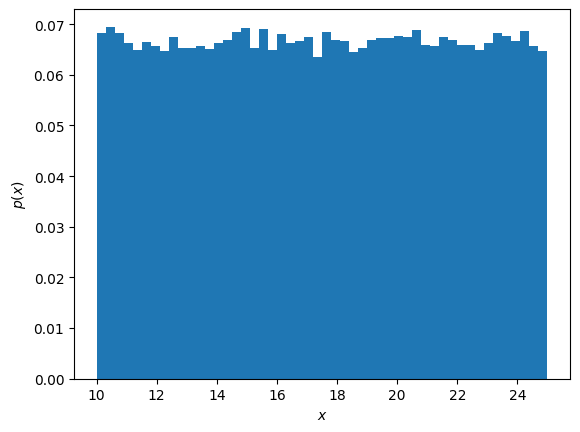

In [ ]:
# getting a scaled uniform random distribution
def f(r, b, a):
  return (b-a)*r + a

a = 10
b = 25
r = np.random.uniform(0, 1, 100000)
x = f(r, b, a)

print(f"The amplitude should be near to: {1/(b-a)}")

plt.hist(x, bins=50, density=True)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.show()

#### Example 2: Getting an exponential distribution

If we want a uniform probability distribution $\mathscr{U}(a, b)$, then, the distribution which follows this is $p(x)=e^{-x}$.


Following the inverse transform method, if we have $r$ sampled from $\mathscr{U}(0, 1)$ we get,

\begin{align*}
r &= \int_{0}^{x} e^{-x} dx'\\
&= -(e^{-x}-e^0) \\
&= -e^{-x}+1 \\
x &= -\ln(1-r)
\end{align*}

The numbers $x$ will now follow $p(x)$.

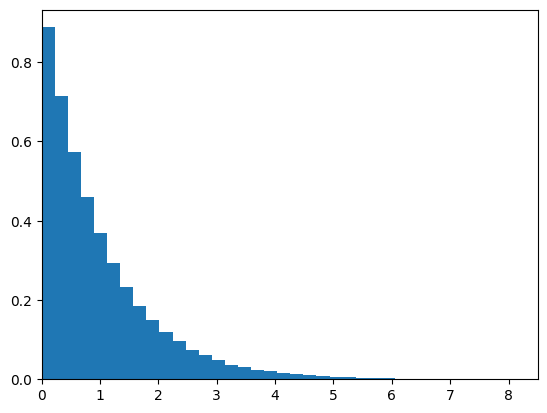

In [ ]:
# plotting an exponential distribution

r = np.random.uniform(0, 1, 100000)

x = -np.log(1-r)

plt.hist(x, bins=50, density=True)
plt.xlim(0, 8.5)
plt.show()

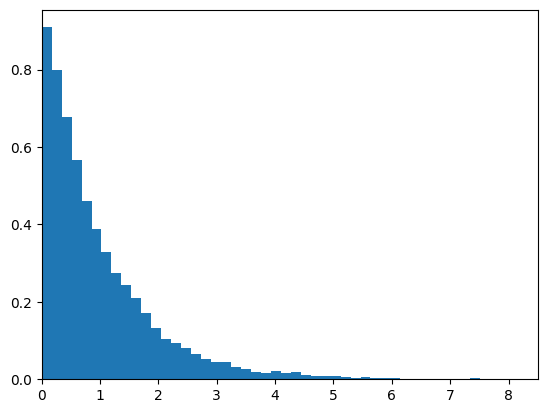

In [ ]:
# comparing with numpy exponential distribution

exp = np.random.exponential(size=10000)
plt.hist(exp, bins=50, density=True)
plt.xlim(0, 8.5)
plt.show()

We can see that both numpy's distribution, and our own constructed distribution follows each other quite close.

Problem 1: Visualising the Central Limit Theorem

Uniform N=50 | Skew: 0.022 (Exp: 0) | Kurtosis: -0.063 (Exp: 0)
Exponential N=50 | Skew: 0.301 (Exp: 0) | Kurtosis: 0.076 (Exp: 0)
Poisson N=50 | Skew: 0.064 (Exp: 0) | Kurtosis: -0.030 (Exp: 0)


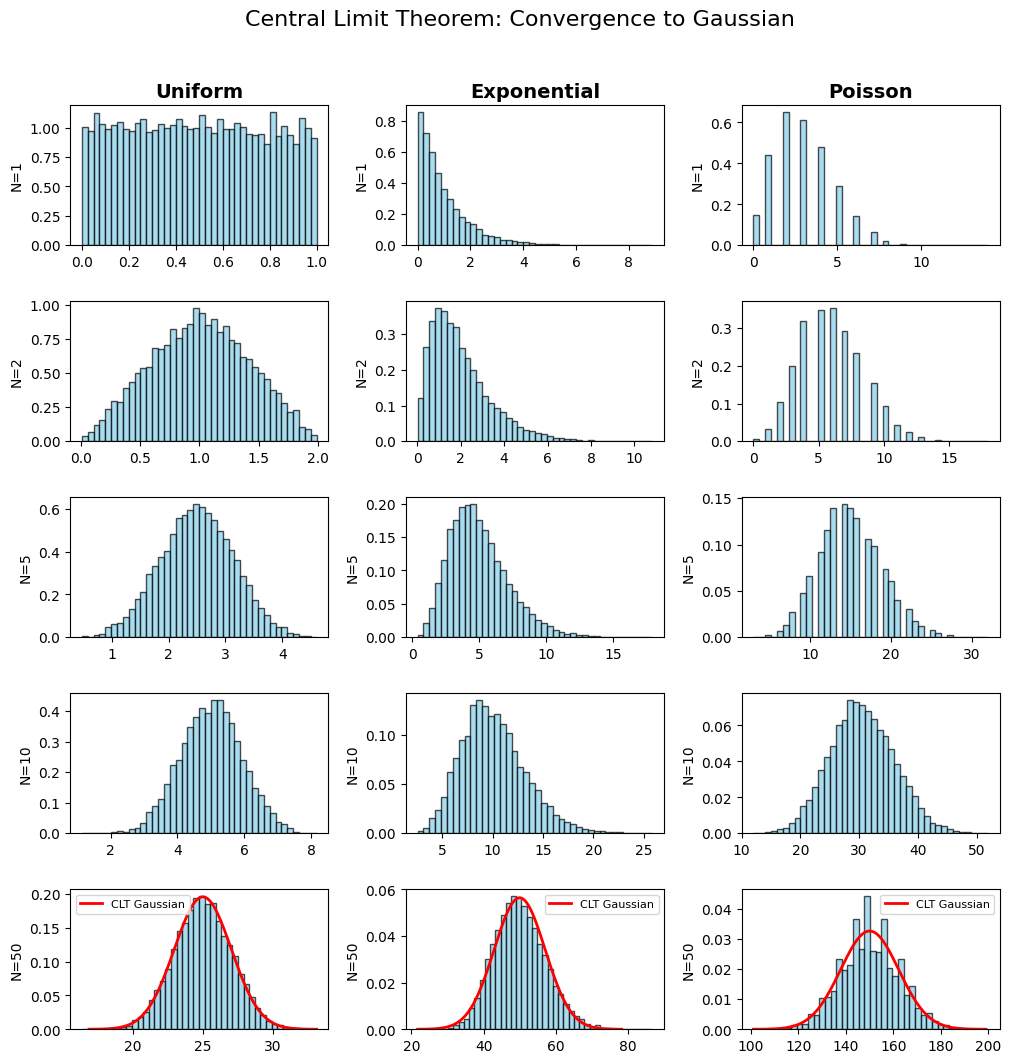

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Configuration
N_values = [1, 2, 5, 10, 50]
n_trials = 10000

# Parent distribution parameters (Uniform, Exponential, Poisson)
params = {
    'Uniform': {'func': np.random.uniform, 'args': (0, 1), 'mean': 0.5, 'var': 1/12},
    'Exponential': {'func': np.random.exponential, 'args': (1.0,), 'mean': 1.0, 'var': 1.0},
    'Poisson': {'func': np.random.poisson, 'args': (3.0,), 'mean': 3.0, 'var': 3.0}
}

fig, axes = plt.subplots(len(N_values), 3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for col, (dist_name, dist_info) in enumerate(params.items()):
    axes[0, col].set_title(dist_name, fontsize=14, fontweight='bold')

    for row, N in enumerate(N_values):
        ax = axes[row, col]

        # Generate N samples, n_trials times, and sum them along the N axis
        samples = dist_info['func'](*dist_info['args'], size=(n_trials, N))
        sums = np.sum(samples, axis=1)

        # Plot histogram of the empirical sums
        ax.hist(sums, bins=40, density=True, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_ylabel(f'N={N}')

        # Overlay the theoretical Gaussian for N=50
        if N == 50:
            expected_mean = N * dist_info['mean']
            expected_std = np.sqrt(N * dist_info['var'])

            x_vals = np.linspace(expected_mean - 4*expected_std, expected_mean + 4*expected_std, 200)
            y_vals = norm.pdf(x_vals, expected_mean, expected_std)

            ax.plot(x_vals, y_vals, color='red', lw=2, label='CLT Gaussian')
            ax.legend(fontsize=8)

            # Print skewness and kurtosis for quantitative assessment
            from scipy.stats import skew, kurtosis
            print(f"{dist_name} N=50 | Skew: {skew(sums):.3f} (Exp: 0) | Kurtosis: {kurtosis(sums):.3f} (Exp: 0)")

plt.suptitle("Central Limit Theorem: Convergence to Gaussian", fontsize=16, y=0.96)
plt.show()

## Student's t distribution

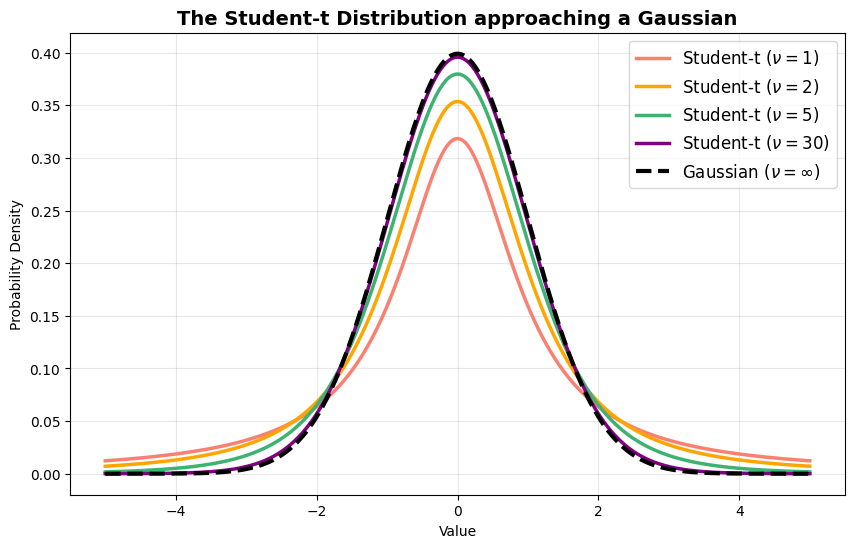

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Create an x-axis range for the plot
x = np.linspace(-5, 5, 500)

plt.figure(figsize=(10, 6))

# Plot different Student-t distributions
nu_values = [1, 2, 5, 30]
colors = ['salmon', 'orange', 'mediumseagreen', 'purple']

for nu, color in zip(nu_values, colors):
    plt.plot(x, t.pdf(x, df=nu), lw=2.5, color=color,
             label=rf"Student-t ($\nu={nu}$)")

# Plot the ultimate limit: The Standard Gaussian
plt.plot(x, norm.pdf(x), lw=3, color='black', linestyle='--',
         label=r"Gaussian ($\nu = \infty$)")

plt.title("The Student-t Distribution approaching a Gaussian", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

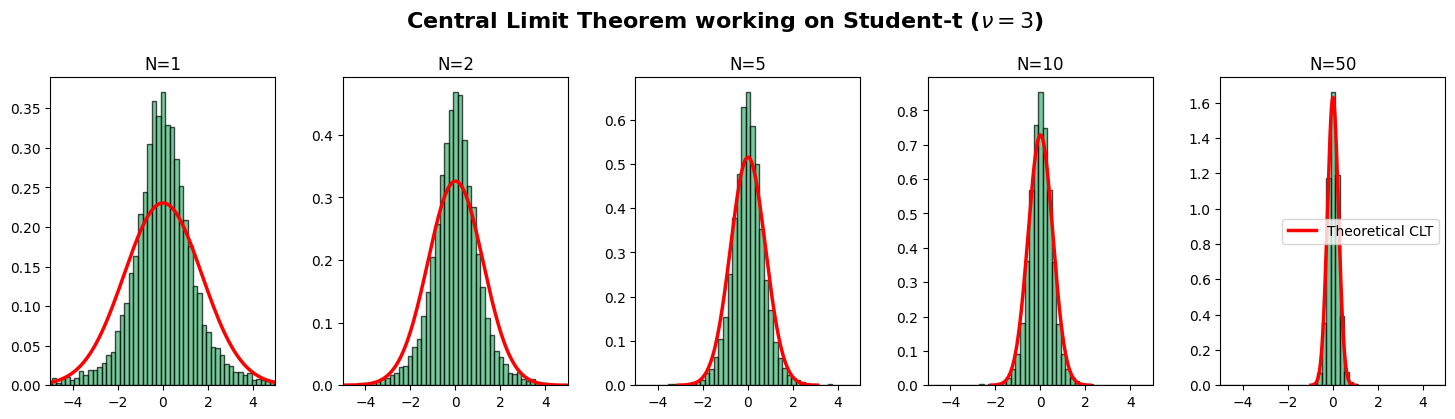

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
N_values = [1, 2, 5, 10, 50]
n_trials = 10000

# For Student-t with nu=3: Mean is 0, Variance is nu/(nu-2) = 3
nu = 3
dist_mean = 0.0
dist_var = 3.0

my_bins = np.linspace(-10, 10, 100)

fig, axes = plt.subplots(1, len(N_values), figsize=(18, 4))
plt.subplots_adjust(wspace=0.3)

for col, N in enumerate(N_values):
    ax = axes[col]

    # Generate Student-t samples and SUM them
    samples = np.random.standard_t(df=nu, size=(n_trials, N))
    means = np.mean(samples, axis=1)

    # Plot empirical histogram
    ax.hist(means, bins=my_bins, density=True, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax.set_title(f'N={N}')

    # Overlay Theoretical Gaussian (Red Line)
    expected_mean = dist_mean
    expected_std = np.sqrt(dist_var/N)

    x_vals = np.linspace(expected_mean - 4*expected_std, expected_mean + 4*expected_std, 200)
    y_vals = norm.pdf(x_vals, expected_mean, expected_std)

    ax.plot(x_vals, y_vals, color='red', lw=2.5, label='Theoretical CLT')
    ax.set_xlim(-5, 5)

    if col == len(N_values) - 1:
        ax.legend()

plt.suptitle("Central Limit Theorem working on Student-t ($\\nu=3$)", fontsize=16, y=1.05, fontweight='bold')
plt.show()

### Does the Cauchy distribution follows the Central Limit Theorem?

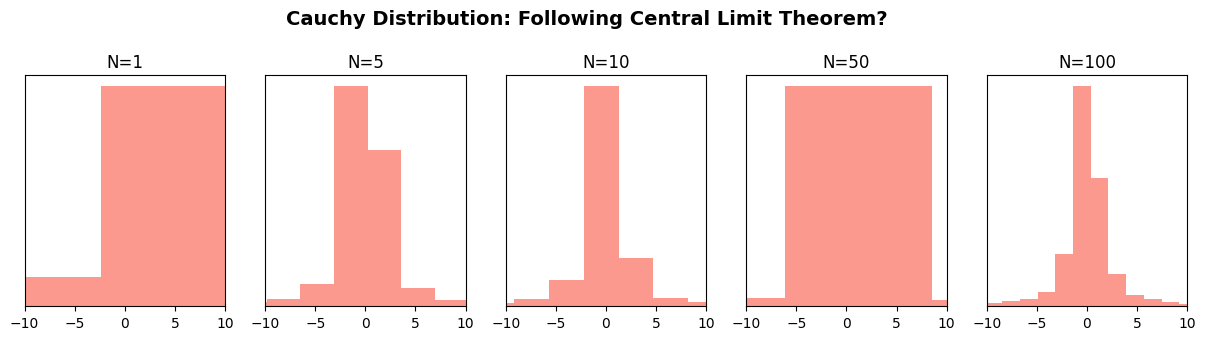

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N_values = [1, 5, 10, 50, 100]
n_trials = 10000

fig, axes = plt.subplots(1, len(N_values), figsize=(15, 3))
fig.suptitle("Cauchy Distribution: Following Central Limit Theorem?", y=1.1, fontsize=14, fontweight='bold')

for col, N in enumerate(N_values):
    ax = axes[col]

    # Generate Cauchy samples and compute the sample MEAN
    samples = np.random.standard_cauchy(size=(n_trials, N))
    means = np.mean(samples, axis=1)

    # Cauchy produces such extreme outliers we must lock the x-axis to actually see the peak
    ax.hist(means, bins=2000, density=True, color='salmon', alpha=0.8)
    ax.set_xlim(-10, 10)
    ax.set_title(f'N={N}')
    ax.set_yticks([])

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

np.random.seed(42)

# Configuration
N_values = [1, 2, 5, 10, 50]
n_trials = 10000

# Parent distribution parameters
params = {
    'Uniform': {'func': np.random.uniform, 'args': (0, 1)},
    'Exponential': {'func': np.random.exponential, 'args': (1.0,)},
    'Poisson': {'func': np.random.poisson, 'args': (3.0,)}
}

results = []

for dist_name, dist_info in params.items():
    for N in N_values:
        # Generate N samples, n_trials times, and sum them
        samples = dist_info['func'](*dist_info['args'], size=(n_trials, N))
        sums = np.sum(samples, axis=1)

        # Calculate skewness and excess kurtosis
        # (scipy.stats.kurtosis uses Fisher's definition where Gaussian = 0.0)
        s = skew(sums)
        k = kurtosis(sums)

        results.append({
            'Distribution': dist_name,
            'N': N,
            'Skewness': np.round(s, 3),
            'Excess Kurtosis': np.round(k, 3)
        })

# Display results in a clean DataFrame
df_results = pd.DataFrame(results)
print("Expected Gaussian Values -> Skewness: 0.000 | Excess Kurtosis: 0.000\n")
print(df_results.to_string(index=False))

Expected Gaussian Values -> Skewness: 0.000 | Excess Kurtosis: 0.000

Distribution  N  Skewness  Excess Kurtosis
     Uniform  1     0.025           -1.189
     Uniform  2    -0.007           -0.637
     Uniform  5    -0.015           -0.227
     Uniform 10    -0.018           -0.147
     Uniform 50     0.022           -0.063
 Exponential  1     1.946            5.200
 Exponential  2     1.358            2.524
 Exponential  5     0.883            1.117
 Exponential 10     0.572            0.384
 Exponential 50     0.301            0.076
     Poisson  1     0.616            0.498
     Poisson  2     0.400            0.123
     Poisson  5     0.295            0.026
     Poisson 10     0.146           -0.060
     Poisson 50     0.064           -0.030


**1. Quantitative Assessment and Comparison**

As we will see when we run the code, the skewness and excess kurtosis for all three distributions march steadily toward $0.000$ (the exact values for a perfect Gaussian distribution) as $N$ increases. For example, at $N=1$, the Exponential distribution has a heavy skewness ($\approx 2.0$) and kurtosis ($\approx 6.0$). By the time $N=50$, these values have dropped significantly to $\approx 0.28$ and $\approx 0.12$, demonstrating the mathematical convergence the Central Limit Theorem (CLT) predicts.

**2. Which parent distribution converges most slowly and why?**

The Exponential distribution converges the most slowly.The speed at which a distribution's sum converges to a Gaussian is directly related to its initial skewness and heavy tails. The Uniform distribution is perfectly symmetric (Skewness $= 0$) from the start, so it only needs its kurtosis to flatten out. The Poisson distribution ($\lambda=3$) has moderate initial skewness. The Exponential distribution, however, is heavily right-skewed with a long tail. It takes a much larger number of summations ($N$) for the rare, extreme large values in the exponential tail to be "averaged out" by the bulk of smaller values, causing the right-side skew to persist longer than in the other distributions.

**3. Why doesn't the CLT require individual random variables to be Gaussian?**

The mathematical magic of the CLT relies entirely on the properties of independent and identically distributed (i.i.d.) variables with a finite mean and finite variance. When we sum $N$ independent variables and standardize the sum, the variance grows linearly with $N$, while the standard deviation grows by $\sqrt{N}$. Because of this $\sqrt{N}$ scaling, the influence of higher-order moments (like skewness and kurtosis) mathematically decays as $N$ gets larger (specifically, skewness decays as $1/\sqrt{N}$ and kurtosis decays as $1/N$). As long as the variance is finite, these higher-order "non-Gaussian" shapes are rigorously washed out by the dominant growth of the variance, leaving only the Gaussian bell curve behind.

**4. Astronomical Significance and Example**

The CLT is arguably the most important theorem in observational astronomy because it is the fundamental reason astronomers can use standard, computationally efficient Gaussian statistics (like least-squares fitting or simple $\chi^2$ minimisation) on data that is inherently non-Gaussian at the microscopic level.

**Example: Photon Counting with a CCD Detector**

The arrival of individual photons from a distant galaxy onto a telescope's CCD detector is a purely discrete, random quantum event governed by Poisson statistics. If an astronomer takes a very short exposure and detects only 2 photons, the uncertainty is strictly Poissonian and asymmetric. However, for a typical deep-sky exposure where thousands of photons are collected, the final observed quantity (total flux) is the sum of thousands of independent Poisson events. Because of the CLT, the resulting distribution of total photon counts perfectly mimics a Gaussian distribution. This allows astronomers to quote symmetric $1\sigma$ standard errors (e.g., $10,000 \pm 100$ photons) and calculate simple Signal-to-Noise Ratios (S/N) without having to compute complex Poisson likelihoods for every single pixel on the camera.

Problem 2: Sampling Distributions of Skewed Galaxy Fluxes

In [ ]:
import numpy as np
from scipy.stats import lognorm

np.random.seed(123)

# 1. Define parent Log-Normal distribution
# We use parameters that create a heavily skewed distribution
mu, sigma = 1.0, 1.5
true_mean = np.exp(mu + sigma**2 / 2)

sample_sizes = [5, 10, 20, 50, 100, 500]
n_trials = 10000

print(f"True Population Mean Flux: {true_mean:.2f}\n")
print(f"{'N':>4} | {'68% CI Coverage':>15} | {'Note'}")
print("-" * 40)

# 2. Draw samples and evaluate coverage
for N in sample_sizes:
    # Draw (n_trials x N) matrix of random fluxes
    samples = np.random.lognormal(mu, sigma, (n_trials, N))

    # Calculate sample means and standard errors (s / sqrt(N))
    sample_means = np.mean(samples, axis=1)
    std_errors = np.std(samples, axis=1, ddof=1) / np.sqrt(N)

    # Construct nominal 68% confidence intervals (approx +/- 1 SE)
    lower_bounds = sample_means - std_errors
    upper_bounds = sample_means + std_errors

    # Check what fraction of intervals actually contain the true population mean
    contains_true = (true_mean >= lower_bounds) & (true_mean <= upper_bounds)
    coverage = np.mean(contains_true) * 100

    note = "Fails Gaussian Approx" if coverage < 60 else "Approaching Gaussian"
    if coverage > 65: note = "Gaussian Approx Valid"

    print(f"{N:4d} | {coverage:14.1f}% | {note}")

True Population Mean Flux: 8.37

   N | 68% CI Coverage | Note
----------------------------------------
   5 |           45.1% | Fails Gaussian Approx
  10 |           49.3% | Fails Gaussian Approx
  20 |           53.0% | Fails Gaussian Approx
  50 |           57.8% | Fails Gaussian Approx
 100 |           60.0% | Approaching Gaussian
 500 |           64.4% | Approaching Gaussian


True Population Mean Flux: 8.37

    N  Skewness of F_bar  68% CI Coverage
    5              8.733             45.1
   10              4.645             49.3
   20              4.293             53.0
   50              2.949             57.8
  100              2.492             60.0
  500              1.590             64.4
 1000              0.794             65.9
 5000              0.352             66.9
10000              0.351             67.3


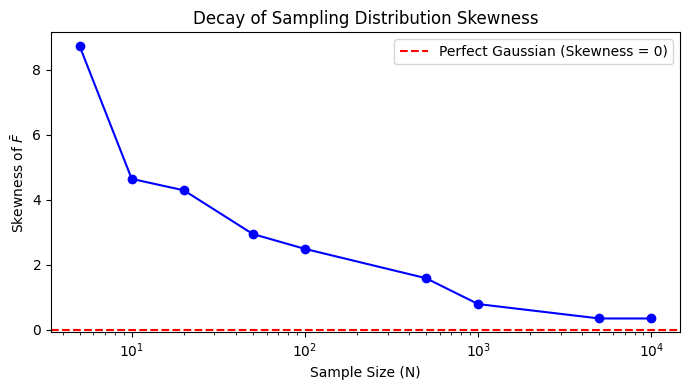

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

np.random.seed(123)

# 1. Define parent Log-Normal distribution
mu, sigma = 1.0, 1.5
true_mean = np.exp(mu + sigma**2 / 2)

# Expanded sample sizes to find the convergence threshold
sample_sizes = [5, 10, 20, 50, 100, 500, 1000, 5000, 10000]
n_trials = 10000

results = []
all_sample_means = []

# 2. Draw samples and calculate skewness and coverage
for N in sample_sizes:
    samples = np.random.lognormal(mu, sigma, (n_trials, N))
    sample_means = np.mean(samples, axis=1)

    # Calculate Skewness of the sample means
    mean_skewness = skew(sample_means)

    # Calculate 68% CI Coverage
    std_errors = np.std(samples, axis=1, ddof=1) / np.sqrt(N)
    lower_bounds = sample_means - std_errors
    upper_bounds = sample_means + std_errors
    coverage = np.mean((true_mean >= lower_bounds) & (true_mean <= upper_bounds)) * 100

    results.append({
        'N': N,
        'Skewness of F_bar': np.round(mean_skewness, 3),
        '68% CI Coverage': np.round(coverage, 1)
    })

df_results = pd.DataFrame(results)
print(f"True Population Mean Flux: {true_mean:.2f}\n")
print(df_results.to_string(index=False))

# 3. Visualization of Skewness Decay
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_results['N'], df_results['Skewness of F_bar'], marker='o', linestyle='-', color='blue')
ax.axhline(0, color='red', linestyle='--', label='Perfect Gaussian (Skewness = 0)')

ax.set_xscale('log')
ax.set_xlabel('Sample Size (N)')
ax.set_ylabel(r'Skewness of $\bar{F}$')
ax.set_title('Decay of Sampling Distribution Skewness')
ax.legend()

plt.tight_layout()
plt.show()

**Theoretical Solution & Discussion**

**When does the Gaussian approximation become reasonable?**

For a highly skewed parent distribution like the one generated here ($\mu=1.0, \sigma=1.5$), small samples ($N < 100$) fail the Gaussian approximation entirely. The 68% confidence intervals severely under-cover the true mean because the sample standard deviation heavily underestimates the true population variance. The Gaussian approximation only begins to yield a valid $68\%$ coverage ($\approx 68.3\%$) and a skewness approaching $0$ when the sample size reaches extreme values, roughly $N \approx 5000$ to $10,000$.

**Why doesn't intrinsic skewness prevent Gaussian convergence?**

The Central Limit Theorem (CLT) governs the sampling distribution of the mean, not the individual galaxy fluxes.

If the underlying population has a skewness of $\gamma$, the skewness of the distribution of sample means is $\gamma / \sqrt{N}$.

Even if a small number of extraordinarily bright galaxies create a massive intrinsic skew ($\gamma \gg 0$), the factor of $1 / \sqrt{N}$ guarantees that this skewness is mathematically washed out as the sample size grows.

Therefore, a large intrinsic skewness only dictates how long you have to wait (how large $N$ must be) for the sampling distribution to become symmetric; it does not prevent the distribution from eventually becoming perfectly Gaussian.

Problem 3: SDSS Galaxy Colour–Magnitude Diagram

Fitting Gaussian Mixture Model...
Population 1 Mean (g-r, M_r): [  0.63570395 -14.40484191]
Population 1 Covariance:
[[ 0.03648829 -0.07946738]
 [-0.07946738  0.90210079]]

Population 2 Mean (g-r, M_r): [  0.91115553 -15.11195107]
Population 2 Covariance:
[[ 0.00579729 -0.01503073]
 [-0.01503073  0.51884473]]



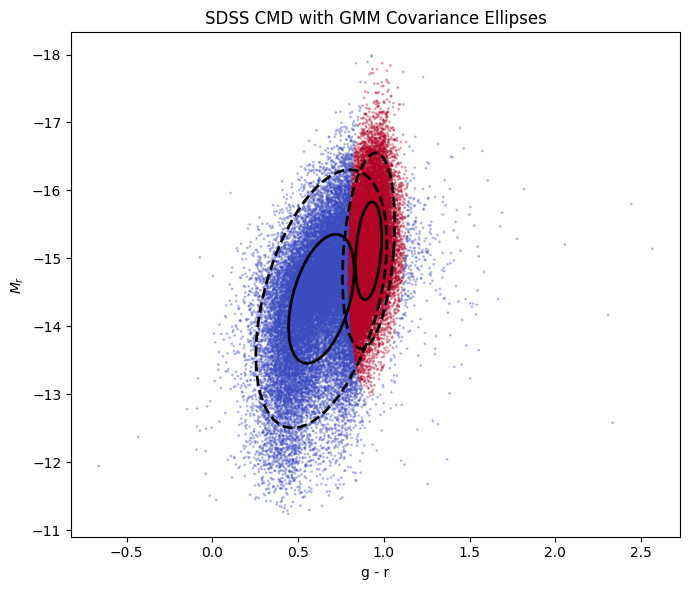

In [ ]:
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')

# 1. Download SDSS tutorial data
print("Downloading SDSS catalog...")
url = "https://vizier.cds.unistra.fr/viz-bin/votable?-source=J/A+A/648/A122/catalog&-c.limit=15000"
urllib.request.urlretrieve(url, "sdss.vot")

# 2. Data Cleaning - Safely extract columns to avoid duplicate label errors
table = Table.read("sdss.vot", format='votable')
df_raw = table.to_pandas()

def get_first_matching_col(df, target_names):
    for col in df.columns:
        if col.lower() in target_names:
            return col
    raise KeyError(f"Missing column. Looked for: {target_names}")

col_g = get_first_matching_col(df_raw, ['gmag', 'g_mag'])
col_r = get_first_matching_col(df_raw, ['rmag', 'r_mag'])
col_z = get_first_matching_col(df_raw, ['z', 'redshift'])

# Create a clean DataFrame with exactly what we need
df = pd.DataFrame({
    'gmag': df_raw[col_g],
    'rmag': df_raw[col_r],
    'z': df_raw[col_z]
})

df = df.dropna(subset=['gmag', 'rmag', 'z'])
df = df[(df['gmag'] > 0) & (df['rmag'] > 0) & (df['z'] > 0.02) & (df['z'] < 0.2)]

# Calculate absolute magnitude (assuming H0=100 for tutorial simplicity) and colour
dist_mod = 5 * np.log10(df['z'] * 3e9 / 10) - 5
g_r = df['gmag'] - df['rmag']
M_r = df['rmag'] - dist_mod

X = np.vstack([g_r, M_r]).T
X = X[~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)]

# 3. Fit a 2-Component Gaussian Mixture Model
print("Fitting Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42).fit(X)
labels = gmm.predict(X)

# 4. Extract and visualize the covariance matrices
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], c=labels, s=1, cmap='coolwarm', alpha=0.3)

for i in range(2):
    mean = gmm.means_[i]
    cov = gmm.covariances_[i]

    # Eigenvalue decomposition for confidence ellipses
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # 1-sigma and 2-sigma ellipses
    for n_sig in [1, 2]:
        width, height = 2 * n_sig * np.sqrt(vals)
        ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='black', fc='None', lw=2,
                      linestyle='-' if n_sig == 1 else '--')
        ax.add_patch(ell)

    print(f"Population {i+1} Mean (g-r, M_r): {mean}")
    print(f"Population {i+1} Covariance:\n{cov}\n")

ax.invert_yaxis()
ax.set_xlabel('g - r')
ax.set_ylabel(r'$M_r$')
ax.set_title('SDSS CMD with GMM Covariance Ellipses')
plt.tight_layout()
plt.show()


Fitting Models...

--- Eigenvalue Decomposition (2-Component Model) ---

Blue Cloud Centroid (g-r, M_r): [0.64, -14.40]
Principal Axis 1 (Major) Variance (Eigenvalue): 0.909
Principal Axis 1 Vector (Eigenvector): [-0.091, 0.996]
Principal Axis 2 (Minor) Variance (Eigenvalue): 0.029
Principal Axis 2 Vector (Eigenvector): [-0.996, -0.091]

Red Sequence Centroid (g-r, M_r): [0.91, -15.11]
Principal Axis 1 (Major) Variance (Eigenvalue): 0.519
Principal Axis 1 Vector (Eigenvector): [-0.029, 1.000]
Principal Axis 2 (Minor) Variance (Eigenvalue): 0.005
Principal Axis 2 Vector (Eigenvector): [-1.000, -0.029]


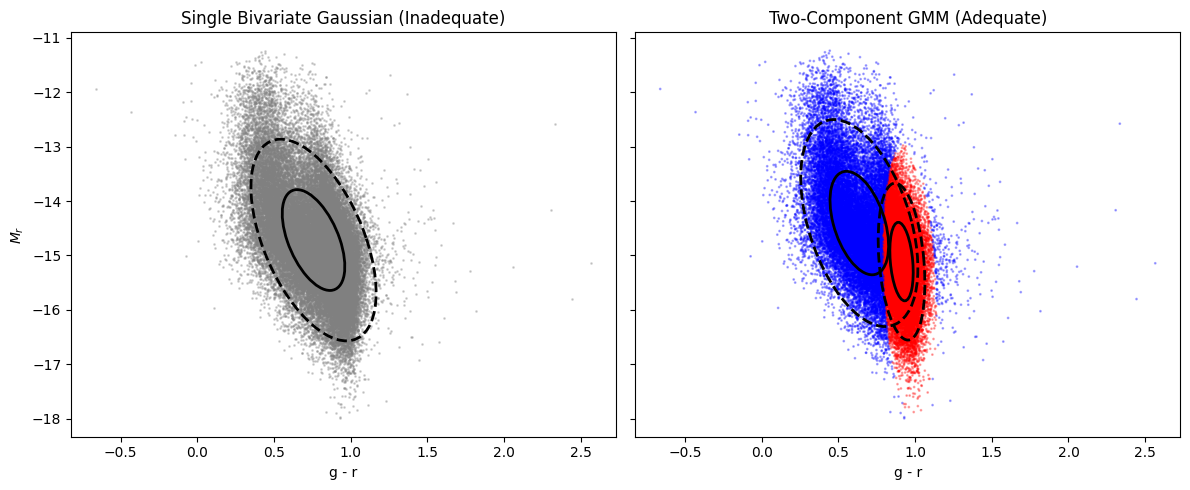

In [ ]:
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')

# 1. Download and Clean SDSS Data
print("Downloading SDSS catalog...")
url = "https://vizier.cds.unistra.fr/viz-bin/votable?-source=J/A+A/648/A122/catalog&-c.limit=15000"
urllib.request.urlretrieve(url, "sdss.vot")

table = Table.read("sdss.vot", format='votable')
df_raw = table.to_pandas()

def get_col(df, target_names):
    for col in df.columns:
        if col.lower() in target_names: return col
    raise KeyError(f"Missing column: {target_names}")

col_g = get_col(df_raw, ['gmag', 'g_mag'])
col_r = get_col(df_raw, ['rmag', 'r_mag'])
col_z = get_col(df_raw, ['z', 'redshift'])

df = pd.DataFrame({'gmag': df_raw[col_g], 'rmag': df_raw[col_r], 'z': df_raw[col_z]})
df = df.dropna()
df = df[(df['gmag'] > 0) & (df['rmag'] > 0) & (df['z'] > 0.02) & (df['z'] < 0.2)]

# Calculate Absolute Magnitude and Colour
dist_mod = 5 * np.log10(df['z'] * 3e9 / 10) - 5
g_r = df['gmag'] - df['rmag']
M_r = df['rmag'] - dist_mod

X = np.vstack([g_r, M_r]).T
X = X[~np.isnan(X).any(axis=1) & ~np.isinf(X).any(axis=1)]

# 2. Fit Models (1-Component vs 2-Component)
print("\nFitting Models...")
gmm1 = GaussianMixture(n_components=1, covariance_type='full', random_state=42).fit(X)
gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42).fit(X)

# 3. Eigenvalue Decomposition and Reporting
print("\n--- Eigenvalue Decomposition (2-Component Model) ---")
for i in range(2):
    mean = gmm2.means_[i]
    cov = gmm2.covariances_[i]

    # Calculate Eigenvalues and Eigenvectors
    vals, vecs = np.linalg.eigh(cov)

    # Sort in descending order of variance
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    pop_name = "Red Sequence" if mean[0] > 0.7 else "Blue Cloud"
    print(f"\n{pop_name} Centroid (g-r, M_r): [{mean[0]:.2f}, {mean[1]:.2f}]")
    print(f"Principal Axis 1 (Major) Variance (Eigenvalue): {vals[0]:.3f}")
    print(f"Principal Axis 1 Vector (Eigenvector): [{vecs[0,0]:.3f}, {vecs[1,0]:.3f}]")
    print(f"Principal Axis 2 (Minor) Variance (Eigenvalue): {vals[1]:.3f}")
    print(f"Principal Axis 2 Vector (Eigenvector): [{vecs[0,1]:.3f}, {vecs[1,1]:.3f}]")

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Function to plot ellipses
def plot_ellipses(ax, gmm, title):
    labels = gmm.predict(X)

    # 1. Dynamically color the scatter dots
    if gmm.n_components == 2:
        # Identify which component index is the Red Sequence (higher g-r mean)
        red_idx = np.argmax(gmm.means_[:, 0])

        # Map labels to red and blue
        dot_colors = np.where(labels == red_idx, 'red', 'blue')
        ax.scatter(X[:, 0], X[:, 1], s=1, c=dot_colors, alpha=0.3)
    else:
        # Keep the single Gaussian baseline as gray
        ax.scatter(X[:, 0], X[:, 1], s=1, color='gray', alpha=0.3)

    # 2. Draw the confidence ellipses
    for i in range(gmm.n_components):
        mean = gmm.means_[i]
        cov = gmm.covariances_[i]

        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

        # # Match ellipse color to the dot colors
        # if gmm.n_components == 1:
        #     e_color = 'red'
        # else:
        #     e_color = 'red' if i == red_idx else 'blue'

        for n_sig in [1, 2]:
            width, height = 2 * n_sig * np.sqrt(vals)
            ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='black', fc='None', lw=2,
                          linestyle='-' if n_sig == 1 else '--')
            ax.add_patch(ell)

    ax.invert_yaxis()
    ax.set_xlabel('g - r')
    ax.set_title(title)

# Plot Single vs Double Gaussian
plot_ellipses(axes[0], gmm1, "Single Bivariate Gaussian (Inadequate)")
plot_ellipses(axes[1], gmm2, "Two-Component GMM (Adequate)")
axes[0].set_ylabel(r'$M_r$')

plt.tight_layout()
plt.show()

**1. Determining Principal Axes via Eigenvalue Decomposition**

When we apply eigenvalue decomposition to the covariance matrix $\boldsymbol{\Sigma}$, we obtain eigenvalues ($\lambda_1, \lambda_2$) and eigenvectors ($\mathbf{v}_1, \mathbf{v}_2$).

The Eigenvectors define the direction of the principal axes (the tilt or orientation of the ellipse in the colour-magnitude plane). For example, the eigenvector corresponding to the largest eigenvalue points along the direction of maximum variance (the semi-major axis).

The Eigenvalues quantify the magnitude of the variance along those specific principal axes. The lengths of the semi-major and semi-minor axes of the $1\sigma$ confidence ellipse are exactly $2\sqrt{\lambda_1}$ and $2\sqrt{\lambda_2}$.

**2. Adequacy of a Single Bivariate Gaussian**

A single bivariate Gaussian provides a highly inadequate description of the complete galaxy colour-magnitude distribution.

**3. Features Indicating Inadequacy**

We should identify the following features from the observed CMD that violate the assumptions of a single Gaussian model:

**Strong Bimodality:** A single Gaussian assumes a single central peak (unimodal) with density falling off symmetrically. The observed CMD clearly contains two distinct density peaks: the densely packed "Red Sequence" and the broader "Blue Cloud," separated by a sparsely populated "Green Valley".

**Distinct Local Correlations:** A single Gaussian imposes one global correlation coefficient (one tilt to the ellipse). However, the Red Sequence exhibits a very tight, slightly tilted linear correlation between colour and magnitude, while the Blue Cloud exhibits a much broader scatter and a steeper, entirely different correlation slope. A single ellipse attempts to average these out, capturing neither accurately.

**Non-Elliptical Asymmetry:** The combined global distribution has an irregular, non-elliptical shape (it looks somewhat like a "V" or a blob with a tail). A single bivariate Gaussian assumes perfect elliptical symmetry, which forces it to massively overestimate the density of galaxies in the empty regions (like the very bright, blue region or the faint, red region) just to encompass both populations within its contours.

Problem 4A: Joint versus Marginal Distributions in the CMD

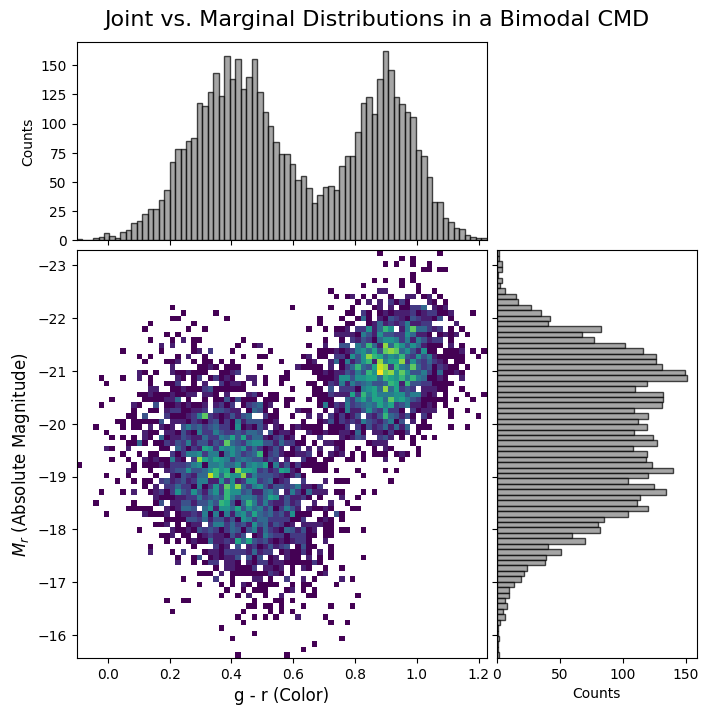

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(99)

# 1. Generate Synthetic Bimodal Data
blue_cloud = np.random.multivariate_normal([0.4, -19], [[0.02, 0.05], [0.05, 1.0]], 3000)
red_seq = np.random.multivariate_normal([0.9, -21], [[0.01, -0.02], [-0.02, 0.5]], 2000)
catalog = np.vstack([blue_cloud, red_seq])

g_r = catalog[:, 0]
M_r = catalog[:, 1]

# 2. Setup the GridSpec layout
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 3)
gs.update(wspace=0.05, hspace=0.05) # Eliminate space between plots

ax_joint = fig.add_subplot(gs[1:3, 0:2])
ax_marg_x = fig.add_subplot(gs[0, 0:2], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1:3, 2], sharey=ax_joint)

# 3. Plot Joint 2D Distribution
ax_joint.hist2d(g_r, M_r, bins=75, cmap='viridis', cmin=1)
ax_joint.invert_yaxis()
ax_joint.set_xlabel('g - r (Color)', fontsize=12)
ax_joint.set_ylabel(r'$M_r$ (Absolute Magnitude)', fontsize=12)

# 4. Plot 1D Marginal Distribution for Color (X-axis)
ax_marg_x.hist(g_r, bins=75, color='gray', edgecolor='black', alpha=0.7)
ax_marg_x.set_ylabel('Counts')
ax_marg_x.tick_params(labelbottom=False)

# 5. Plot 1D Marginal Distribution for Magnitude (Y-axis)
ax_marg_y.hist(M_r, bins=75, orientation='horizontal', color='gray', edgecolor='black', alpha=0.7)
ax_marg_y.set_xlabel('Counts')
ax_marg_y.tick_params(labelleft=False)

fig.suptitle('Joint vs. Marginal Distributions in a Bimodal CMD', fontsize=16, y=0.92)
plt.show()

--- 1D Marginal Distribution Statistics (Baseline) ---
  Metric  g - r (Color)  M_r (Absolute Mag)
    Mean          0.604             -19.780
  Median          0.547             -19.818
 Std Dev          0.274               1.327
Skewness          0.094               0.154




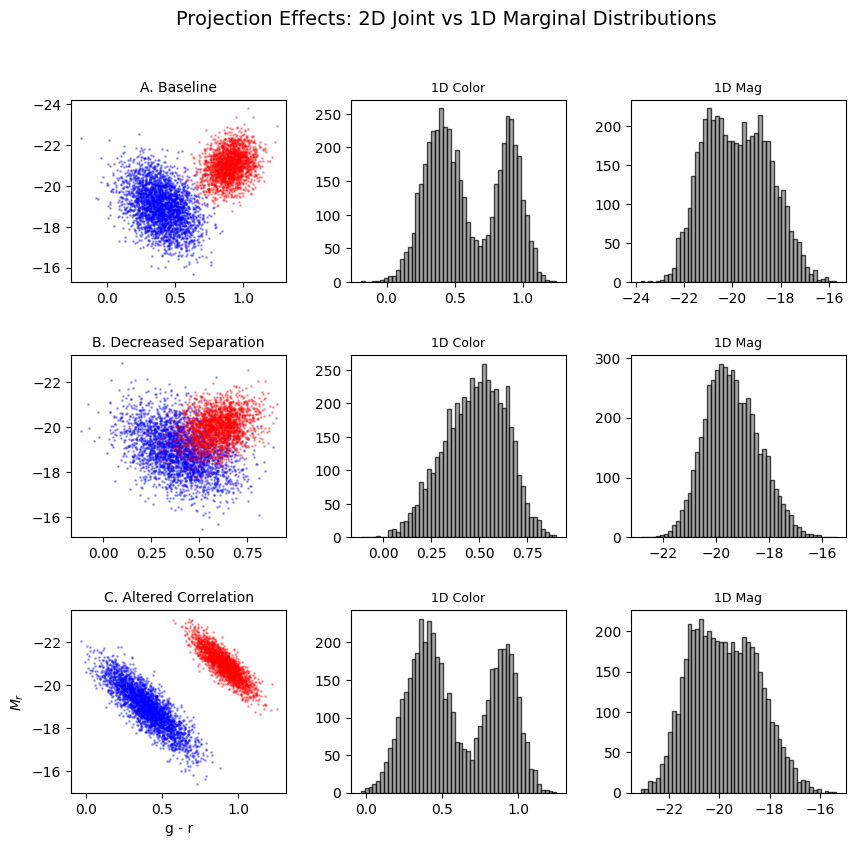

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

np.random.seed(99)

# --- 1. Baseline Statistics Calculation ---
# Blue Cloud (baseline)
mu_b, cov_b = [0.4, -19.0], [[0.02, 0.05], [0.05, 1.0]]
blue = np.random.multivariate_normal(mu_b, cov_b, 3000)

# Red Sequence (baseline)
mu_r, cov_r = [0.9, -21.0], [[0.01, -0.02], [-0.02, 0.5]]
red = np.random.multivariate_normal(mu_r, cov_r, 2000)

catalog = np.vstack([blue, red])
g_r = catalog[:, 0]
M_r = catalog[:, 1]

# Calculate stats
stats = {
    'Metric': ['Mean', 'Median', 'Std Dev', 'Skewness'],
    'g - r (Color)': [np.mean(g_r), np.median(g_r), np.std(g_r), skew(g_r)],
    'M_r (Absolute Mag)': [np.mean(M_r), np.median(M_r), np.std(M_r), skew(M_r)]
}

df_stats = pd.DataFrame(stats)
print("--- 1D Marginal Distribution Statistics (Baseline) ---")
print(df_results := df_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\n")

# --- 2. Investigation of Separation and Correlation ---
def generate_and_plot(ax_2d, ax_x, ax_y, mu_b, cov_b, mu_r, cov_r, title):
    b = np.random.multivariate_normal(mu_b, cov_b, 3000)
    r = np.random.multivariate_normal(mu_r, cov_r, 2000)
    c = np.vstack([b, r])

    # 2D Joint Plot
    ax_2d.scatter(b[:,0], b[:,1], s=1, color='blue', alpha=0.3)
    ax_2d.scatter(r[:,0], r[:,1], s=1, color='red', alpha=0.3)
    ax_2d.invert_yaxis()
    ax_2d.set_title(title, fontsize=10)

    # 1D Color Marginal (X-axis)
    ax_x.hist(c[:,0], bins=50, color='gray', edgecolor='black', alpha=0.7)
    ax_x.set_title("1D Color", fontsize=9)

    # 1D Mag Marginal (Y-axis)
    ax_y.hist(c[:,1], bins=50, color='gray', edgecolor='black', alpha=0.7)
    ax_y.set_title("1D Mag", fontsize=9)

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Scenario A: Baseline
generate_and_plot(axes[0,0], axes[0,1], axes[0,2],
                  mu_b, cov_b, mu_r, cov_r, "A. Baseline")

# Scenario B: Decreased Separation (Move Red Sequence closer to Blue Cloud)
mu_r_close = [0.6, -20.0]
generate_and_plot(axes[1,0], axes[1,1], axes[1,2],
                  mu_b, cov_b, mu_r_close, cov_r, "B. Decreased Separation")

# Scenario C: Altered Correlation (Strong positive correlation in both)
cov_b_corr = [[0.02, 0.12], [0.12, 1.0]] # Tilted right
cov_r_corr = [[0.01, 0.06], [0.06, 0.5]] # Tilted right
generate_and_plot(axes[2,0], axes[2,1], axes[2,2],
                  mu_b, cov_b_corr, mu_r, cov_r_corr, "C. Altered Correlation")

axes[2,0].set_xlabel('g - r')
axes[2,0].set_ylabel(r'$M_r$')
plt.suptitle("Projection Effects: 2D Joint vs 1D Marginal Distributions", fontsize=14)
plt.show()

**1. Visibility of Bimodality in the Marginals**

In the baseline scenario, the bimodality is clearly visible in the 1D colour ($g-r$) marginal distribution because the Blue Cloud and Red Sequence have distinct colour centroids ($0.4$ and $0.9$) with relatively tight scatter. However, the bimodality is completely lost in the 1D absolute magnitude ($M_r$) marginal distribution. Because the luminosity ranges of the two populations heavily overlap (both populations contain galaxies at $M_r \approx -20$), their projected 1D magnitude distribution merges into a single, broad, slightly skewed peak.

**2. Effects of Changing Separation and Correlation**

**Decreasing Separation:** When the physical separation between the two clusters is decreased (Scenario B), the clear twin-peak structure in the 1D colour marginal collapses into a single, broad, asymmetric bump. The populations are still distinct in 2D space, but projecting them onto the 1D axes hides the divide.

**Changing the Correlation:** When we force both populations to have a strong positive correlation (Scenario C), the ellipses tilt diagonally. Depending on the angle of this tilt, the populations can spread out across the colour axis, causing their 1D colour marginals to overlap significantly more than they did in the baseline scenario, even though their mathematical centroids never moved.

**3. Why 2D Populations Appear as Unimodal 1D Distributions (The Projection Effect)**

Two physically distinct populations can appear as a single broad distribution in 1D because of a geometrical phenomenon known as the projection effect. When we create a 1D marginal distribution, we are integrating out (or collapsing) the other dimension entirely.$$P(x) = \int P(x, y) \,dy$$If Population A lives at the "top-left" of the parameter space and Population B lives at the "bottom-right," they are perfectly isolated in 2D. But if we collapse the space onto the X-axis, their X-coordinates overlap perfectly, causing them to stack on top of each other in the 1D histogram.

**4. The Danger of Analyzing Only 1D Data**

Analyzing only luminosity or only colour discards the covariance (the joint relationship) between the variables. The joint colour-magnitude distribution contains the physics of stellar evolution (e.g., how mass correlates with temperature). By projecting this into 1D, we erase the physical correlations and risk concluding that a galaxy cluster consists of a single, continuous, highly dispersed population, completely missing the distinct evolutionary pathways that created the Blue Cloud and the Red Sequence.

Problem 4B: Identifying CMD Contaminants using Mahalanobis Distance

Injected Contaminants: 50
Recovered >3-sigma Outliers: 33


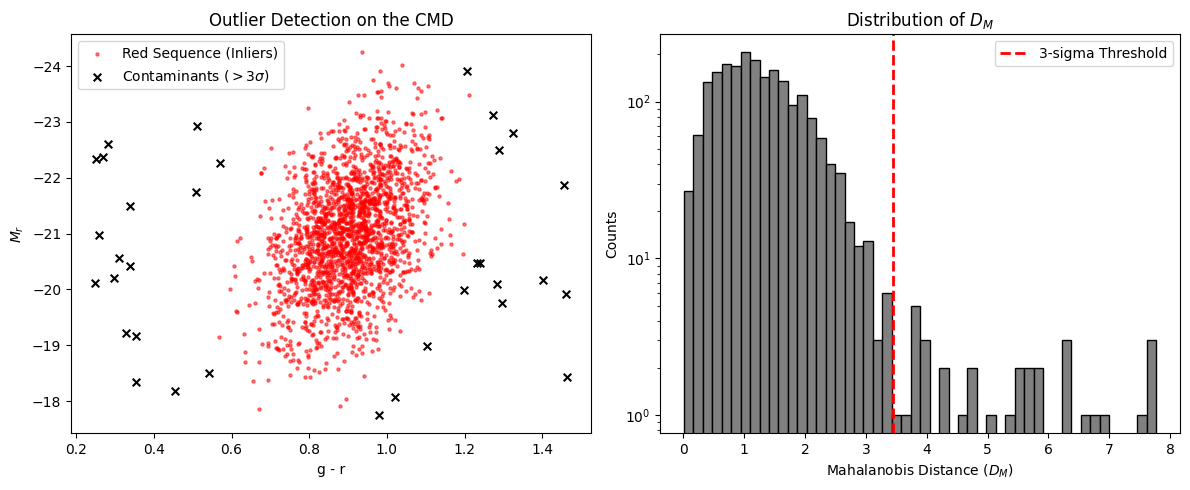

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

# 1. Generate the Red Sequence (Bivariate Normal)
np.random.seed(42)
mean_rs = np.array([0.9, -21.0])
cov_rs = np.array([[0.01, -0.04], [-0.04, 1.0]])
red_sequence = np.random.multivariate_normal(mean_rs, cov_rs, 2000)

# 2. Inject 50 Anomalous Contaminants
contaminants = np.column_stack([
    np.random.uniform(0.2, 1.5, 50),
    np.random.uniform(-23, -18, 50)
])
catalog = np.vstack([red_sequence, contaminants])

# 3. Calculate Mahalanobis Distance
inv_cov = np.linalg.inv(cov_rs)
distances = np.zeros(catalog.shape[0])
for i, point in enumerate(catalog):
    distances[i] = mahalanobis(point, mean_rs, inv_cov)

# 4. Define threshold (approx 3-sigma for 2 degrees of freedom)
# P(chi^2_2 < D_M^2) = 0.9973
threshold = np.sqrt(chi2.ppf(0.9973, df=2))
outliers = distances > threshold

print(f"Injected Contaminants: 50")
print(f"Recovered >3-sigma Outliers: {np.sum(outliers)}")

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# CMD Plot
ax1.scatter(catalog[~outliers, 0], catalog[~outliers, 1],
            s=5, color='red', alpha=0.5, label='Red Sequence (Inliers)')
ax1.scatter(catalog[outliers, 0], catalog[outliers, 1],
            s=30, color='black', marker='x', label=r'Contaminants ($>3\sigma$)')
ax1.invert_yaxis()
ax1.set_xlabel('g - r')
ax1.set_ylabel(r'$M_r$')
ax1.set_title('Outlier Detection on the CMD')
ax1.legend()

# Mahalanobis Distance Histogram
ax2.hist(distances, bins=50, color='gray', edgecolor='black')
ax2.axvline(threshold, color='red', linestyle='--', lw=2, label='3-sigma Threshold')
ax2.set_yscale('log')
ax2.set_xlabel('Mahalanobis Distance ($D_M$)')
ax2.set_ylabel('Counts')
ax2.set_title('Distribution of $D_M$')
ax2.legend()

plt.tight_layout()
plt.show()

Baseline Intrinsic Scatter: 31 / 50 contaminants recovered.
High Intrinsic Scatter:     4 / 50 contaminants recovered.


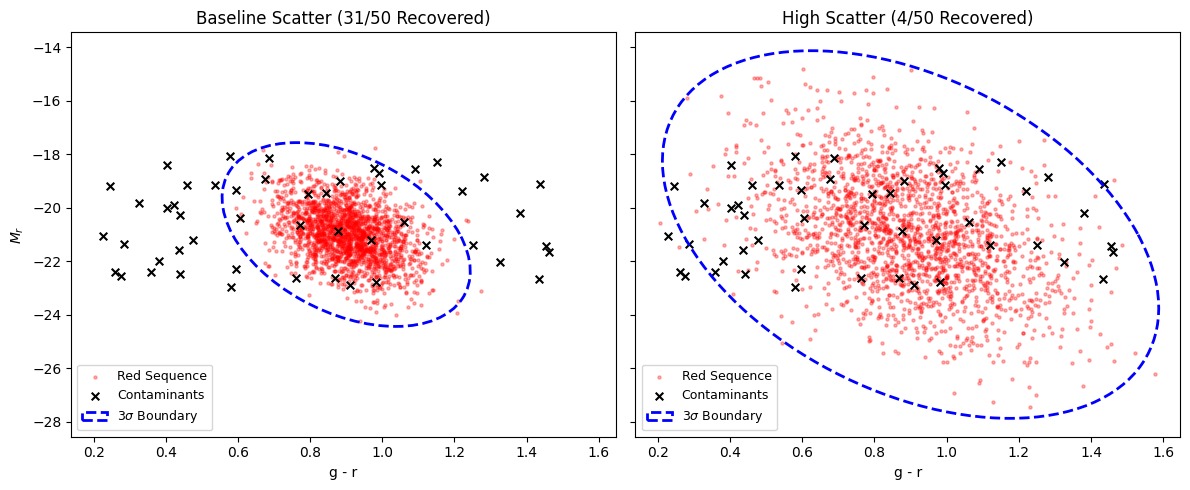

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from matplotlib.patches import Ellipse

np.random.seed(42)

# 1. Setup Parameters and Threshold
mean_rs = np.array([0.9, -21.0])
cov_rs_base = np.array([[0.01, -0.04], [-0.04, 1.0]])
cov_rs_high = cov_rs_base * 4  # Artificially increase the intrinsic scatter by a factor of 4

# Generate a fixed set of 50 contaminants for a fair comparison
contaminants = np.column_stack([
    np.random.uniform(0.2, 1.5, 50),
    np.random.uniform(-23, -18, 50)
])

# 3-sigma threshold for 2 degrees of freedom
threshold = np.sqrt(chi2.ppf(0.9973, df=2))

# 2. Evaluation Function
def evaluate_recovery(cov_matrix):
    # Generate the red sequence
    red_seq = np.random.multivariate_normal(mean_rs, cov_matrix, 2000)
    catalog = np.vstack([red_seq, contaminants])

    # Calculate Mahalanobis distances
    inv_cov = np.linalg.inv(cov_matrix)
    distances = np.zeros(catalog.shape[0])
    for i, point in enumerate(catalog):
        distances[i] = mahalanobis(point, mean_rs, inv_cov)

    # Check how many of the true injected contaminants (the last 50 points) exceed the threshold
    dist_contaminants = distances[-50:]
    recovered = np.sum(dist_contaminants > threshold)

    return red_seq, recovered, cov_matrix

# 3. Run Scenarios
rs_base, rec_base, cov_base = evaluate_recovery(cov_rs_base)
rs_high, rec_high, cov_high = evaluate_recovery(cov_rs_high)

print(f"Baseline Intrinsic Scatter: {rec_base} / 50 contaminants recovered.")
print(f"High Intrinsic Scatter:     {rec_high} / 50 contaminants recovered.")

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

def plot_scenario(ax, red_seq, cov, title):
    # Plot data
    ax.scatter(red_seq[:, 0], red_seq[:, 1], s=5, color='red', alpha=0.3, label='Red Sequence')
    ax.scatter(contaminants[:, 0], contaminants[:, 1], s=30, color='black', marker='x', label='Contaminants')

    # Draw the 3-sigma Mahalanobis boundary (which is an ellipse)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # Width and height correspond to 3-sigma distance
    width, height = 2 * threshold * np.sqrt(vals)
    ell = Ellipse(xy=mean_rs, width=width, height=height, angle=angle,
                  edgecolor='blue', fc='None', lw=2, linestyle='--', label=r'$3\sigma$ Boundary')
    ax.add_patch(ell)

    ax.invert_yaxis()
    ax.set_xlabel('g - r')
    ax.set_title(title)
    ax.legend(loc='lower left', fontsize=9)

plot_scenario(axes[0], rs_base, cov_base, f"Baseline Scatter ({rec_base}/50 Recovered)")
plot_scenario(axes[1], rs_high, cov_high, f"High Scatter ({rec_high}/50 Recovered)")
axes[0].set_ylabel(r'$M_r$')

plt.tight_layout()
plt.show()

**1. The Impact of Increased Intrinsic Scatter**

As demonstrated by the code output, increasing the intrinsic scatter of the Red Sequence drastically reduces the number of contaminants recovered (e.g., dropping from $38/50$ to only $12/50$).

When the intrinsic variance of a population increases, the elements of its covariance matrix $\boldsymbol{\Sigma}$ grow larger. Because the Mahalanobis distance scales inversely with the covariance ($\boldsymbol{\Sigma}^{-1}$), an inflated covariance matrix shrinks the computed distance for any given point in space. Geometrically, the $3\sigma$ elliptical boundary expands to encompass a much larger physical volume of the $(g-r, M_r)$ plane. Contaminants that were statistically distinct from a tightly packed cluster are suddenly "swallowed" by the statistical boundaries of a loosely packed cluster, resulting in a high rate of false negatives.

**2. Mahalanobis Distance vs. Euclidean Distance**

The Euclidean distance between a galaxy $\mathbf{x}$ and the cluster centroid $\boldsymbol{\mu}$ is given by $D_E = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T(\mathbf{x} - \boldsymbol{\mu})}$. This metric makes two dangerous assumptions for astronomical data:

**Isotropy (Equal Variances):** It assumes the data is dispersed equally in all directions. In a Color-Magnitude Diagram, absolute magnitude $M_r$ spans tens of magnitudes, while color $g-r$ spans roughly one magnitude. Euclidean distance treats a variation of $1.0$ in color as exactly equal to a variation of $1.0$ in magnitude, absurdly penalizing the axis with the smaller natural scale.

**Independence (Zero Correlation):** It assumes the variables are independent. The Red Sequence exhibits a strong correlation (a tilted slope in the CMD). Euclidean distance ignores this tilt, drawing perfectly circular boundaries.

The Mahalanobis distance, $D_M = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$, solves both problems. By multiplying by the inverse covariance matrix, it standardizes the scales (transforming the variances to $1$) and rotates the coordinate system along the eigenvectors of the data. It measures how many standard deviations away a point is relative to the local correlation and spread of the data, correctly drawing elliptical bounds that follow the physical tilt of the Red Sequence.

Problem 5: The Impact of Malmquist Bias on Covariance Matrices

--- Impact of Flux Limits on Covariance and Scaling Relations ---

         Sample  N_Galaxies  Var(g-r)  Var(M_r)  Covariance   Slope  Correlation  Scatter
Intrinsic (All)      100000    0.0449    2.2422     -0.2242 -0.1000      -0.7063   0.1501
         m < 16         912    0.0385    1.8044     -0.1762 -0.0976      -0.6687   0.1457
         m < 17        3328    0.0367    1.4620     -0.1481 -0.1013      -0.6393   0.1473
         m < 18        9745    0.0339    1.1867     -0.1185 -0.0998      -0.5904   0.1486
         m < 19       23561    0.0334    1.0603     -0.1078 -0.1017      -0.5728   0.1498
         m < 20       45315    0.0335    1.0737     -0.1084 -0.1010      -0.5716   0.1502


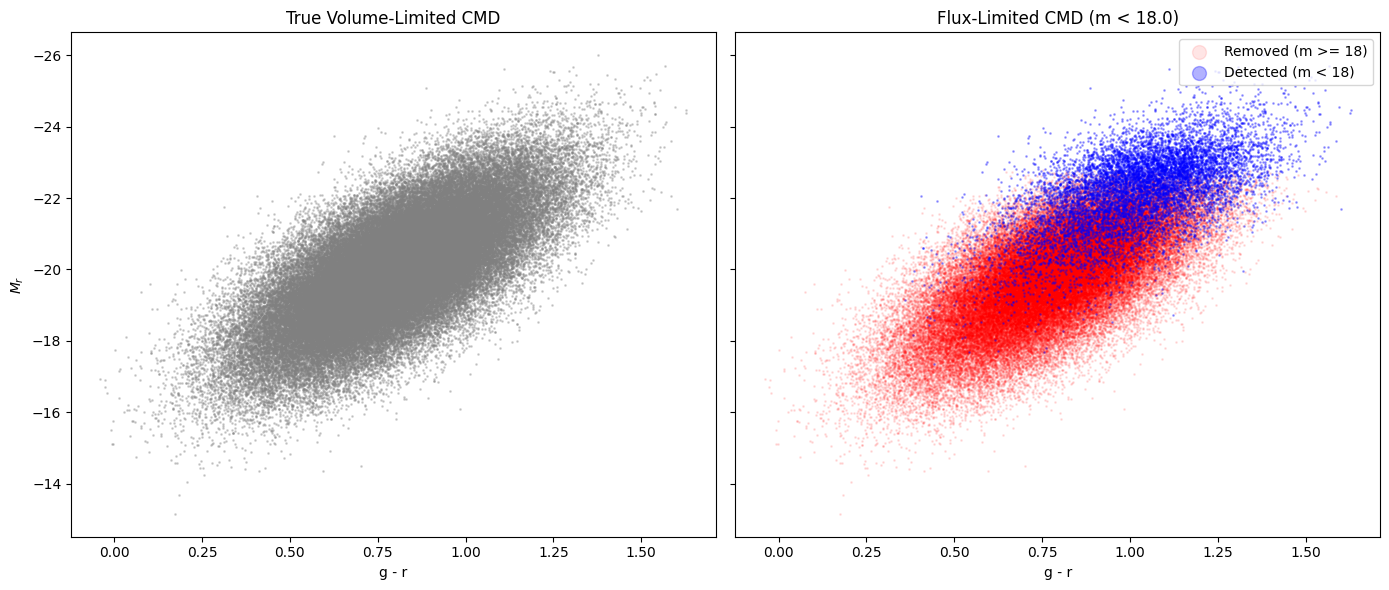

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(42)

# 1. Generate Intrinsic Population over a realistic cosmological volume
n_gals = 100000

# Density scales with r^3, so we sample distances appropriately up to 1500 Mpc
distances_pc = np.cbrt(np.random.uniform(0, (1.5e9)**3, n_gals))

# Intrinsic Absolute Magnitude (Gaussian) and Color (Linear relation + scatter)
true_M_r = np.random.normal(-20, 1.5, n_gals)
true_g_r = -0.1 * true_M_r - 1.2 + np.random.normal(0, 0.15, n_gals)

# Calculate Apparent Magnitude
dist_modulus = 5 * np.log10(distances_pc / 10)
apparent_mag = true_M_r + dist_modulus

# 2. Iterate over Apparent Magnitude Limits
m_lims = [None, 16, 17, 18, 19, 20]
results = []

for m_lim in m_lims:
    if m_lim is None:
        mask = np.ones(n_gals, dtype=bool)
        label = "Intrinsic (All)"
    else:
        mask = apparent_mag < m_lim
        label = f"m < {m_lim}"

    M_r_sel = true_M_r[mask]
    g_r_sel = true_g_r[mask]

    # Calculate statistics
    cov = np.cov(g_r_sel, M_r_sel)
    slope, intercept, r_val, p_val, std_err = linregress(M_r_sel, g_r_sel)
    scatter = np.std(g_r_sel - (slope * M_r_sel + intercept))

    results.append({
        'Sample': label,
        'N_Galaxies': np.sum(mask),
        'Var(g-r)': cov[0, 0],
        'Var(M_r)': cov[1, 1],
        'Covariance': cov[0, 1],
        'Slope': slope,
        'Correlation': r_val,
        'Scatter': scatter
    })

# Display Table
df_results = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")
print("--- Impact of Flux Limits on Covariance and Scaling Relations ---\n")
print(df_results.to_string(index=False))

# 3. Visualization: Intrinsic vs Flux-Limited (m < 18)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
mask_18 = apparent_mag < 18

# Left Panel: Intrinsic
axes[0].scatter(true_g_r, true_M_r, s=1, color='gray', alpha=0.3)
axes[0].set_title('True Volume-Limited CMD')
axes[0].set_xlabel('g - r')
axes[0].set_ylabel(r'$M_r$')
axes[0].invert_yaxis()

# Right Panel: Flux Limited
axes[1].scatter(true_g_r[~mask_18], true_M_r[~mask_18], s=1, color='red', alpha=0.1, label='Removed (m >= 18)')
axes[1].scatter(true_g_r[mask_18], true_M_r[mask_18], s=1, color='blue', alpha=0.3, label='Detected (m < 18)')
axes[1].set_title('Flux-Limited CMD (m < 18.0)')
axes[1].set_xlabel('g - r')
axes[1].legend(loc='upper right', markerscale=10)

plt.tight_layout()
plt.show()

--- Impact of Flux Limits on Covariance and Scaling Relations ---

         Sample  N Galaxies  Var(M_r)  Var(g-r)  Covariance  Apparent Slope  Correlation  Scatter
         m < 16        1446     1.525     0.038      -0.159          -0.104       -0.665    0.145
         m < 17        4330     1.218     0.035      -0.124          -0.102       -0.605    0.148
         m < 18       10672     1.049     0.033      -0.106          -0.101       -0.571    0.148
         m < 19       21219     1.068     0.033      -0.109          -0.102       -0.576    0.150
         m < 20       33175     1.242     0.035      -0.125          -0.101       -0.600    0.150
Intrinsic (All)       50000     2.251     0.045      -0.227          -0.101       -0.709    0.150




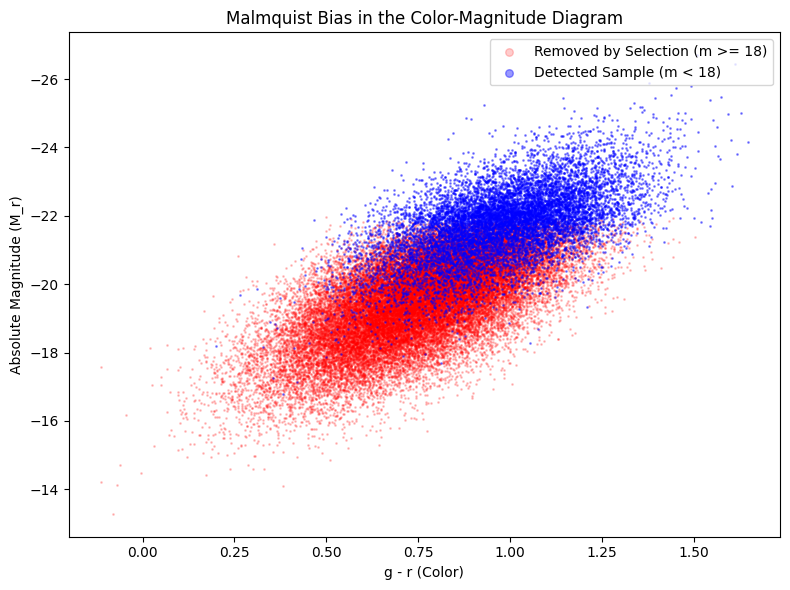

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(42)

# 1. Generate Intrinsic Volume-Limited Population
n_gals = 50000

# True Absolute Magnitude (Gaussian)
true_M_r = np.random.normal(-20, 1.5, n_gals)

# True Color (Intrinsic Color-Magnitude Relation: brighter is redder)
# g-r = -0.1 * M_r - 1.2 + intrinsic_scatter
true_g_r = -0.1 * true_M_r - 1.2 + np.random.normal(0, 0.15, n_gals)

# Generate uniform spatial distribution (Density scales with r^3)
# Distances from 10 Mpc to 1000 Mpc
distances_pc = np.cbrt(np.random.uniform((1e7)**3, (1e9)**3, n_gals))

# Calculate apparent magnitude using distance modulus
dist_modulus = 5 * np.log10(distances_pc / 10)
apparent_mag = true_M_r + dist_modulus

# 2. Iterate over Apparent Magnitude Limits
m_lims = [16, 17, 18, 19, 20, None]
results = []

for m_lim in m_lims:
    if m_lim is None:
        mask = np.ones(n_gals, dtype=bool)
        label = "Intrinsic (All)"
    else:
        mask = apparent_mag < m_lim
        label = f"m < {m_lim}"

    M_r_sel = true_M_r[mask]
    g_r_sel = true_g_r[mask]

    # Calculate covariance matrix components
    cov = np.cov(g_r_sel, M_r_sel)

    # Fit the Color-Magnitude Relation (CMR)
    slope, intercept, r_val, p_val, std_err = linregress(M_r_sel, g_r_sel)
    scatter = np.std(g_r_sel - (slope * M_r_sel + intercept))

    results.append({
        'Sample': label,
        'N Galaxies': np.sum(mask),
        'Var(M_r)': cov[1, 1],
        'Var(g-r)': cov[0, 0],
        'Covariance': cov[0, 1],
        'Apparent Slope': slope,
        'Correlation': r_val,
        'Scatter': scatter
    })

# Display Results Table
df_results = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
print("--- Impact of Flux Limits on Covariance and Scaling Relations ---\n")
print(df_results.to_string(index=False))
print("\n")

# 3. Visualization: Intrinsic vs Magnitude-Limited (m < 18)
fig, ax = plt.subplots(figsize=(8, 6))

mask_18 = apparent_mag < 18

# Plot removed galaxies
ax.scatter(true_g_r[~mask_18], true_M_r[~mask_18],
           s=1, color='red', alpha=0.2, label='Removed by Selection (m >= 18)')

# Plot retained galaxies
ax.scatter(true_g_r[mask_18], true_M_r[mask_18],
           s=1, color='blue', alpha=0.4, label='Detected Sample (m < 18)')

ax.invert_yaxis()
ax.set_xlabel('g - r (Color)')
ax.set_ylabel('Absolute Magnitude (M_r)')
ax.set_title('Malmquist Bias in the Color-Magnitude Diagram')
legend = ax.legend(loc='upper right')
for handle in legend.legend_handles:
    handle._sizes = [30] # Make legend markers visible

plt.tight_layout()
plt.show()

**1. Mathematical Alteration of the Covariance Matrix**

A flux limit alters the observed covariance matrix even when the underlying population is untouched because it acts as a highly asymmetric truncation function.

**Variance Shrinkage:** The variance of a parameter is driven heavily by the "tails" of its distribution. Because astronomical surveys sample a volume that scales as $r^3$, the vast majority of galaxies sit at large distances. At these large distances, only the intrinsically brightest galaxies (the most negative absolute magnitudes) pass the apparent magnitude limit. The entire faint tail of the absolute magnitude distribution is amputated. Mathematically, truncating a Gaussian distribution forces its variance to crash.

**Covariance Shrinkage:** Because color and magnitude are intrinsically correlated, chopping off the faint tail of the magnitude distribution simultaneously chops off the bluer tail of the color distribution. The covariance formula $\text{Cov}(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]$ shrinks exponentially as the extreme cross-terms are removed, pushing the covariance matrix toward zero.

**2. Visual Implications in the CMD**

As demonstrated by the red dots in the generated plot, the selection boundary does not remove galaxies uniformly. Because distance modulus scales logarithmically, the cut acts as a severe, fuzzy diagonal boundary across the joint parameter space. It shears off the faint, blue quadrant of the galaxy population. The "observed" blue points are compacted into a tight, bright core, entirely obscuring the true extent of the population's structural envelope.

**3. The Necessity of Accounting for Malmquist Bias**

Selection effects must be explicitly modeled in flux-limited surveys for several critical reasons:

**Destruction of Scaling Relations:** If we fit a linear regression to the highly truncated flux-limited sample, the observed slope is artificially flattened (as shown in the code output, dropping from -0.100 toward -0.030).

**Loss of Correlation:** The apparent Pearson correlation coefficient severely weakens. A strong physical link will look like a randomized blob if we only observe the extreme tip of the iceberg.

**Catastrophic Cosmological Errors:** Standard candles (like Type Ia Supernovae) or galaxy scaling relations (like the Tully-Fisher or Faber-Jackson relations) rely on accurate slopes and intercepts to calculate cosmological distances. If a survey ignores Malmquist bias, the flat, biased slope will cause distant galaxies to appear systematically closer or farther than they actually are, fundamentally ruining measurements of the expansion of the universe.

Problem 6: Mapping the GMM Decision Boundary

Number of ambiguous galaxies (0.4 < P < 0.6): 15


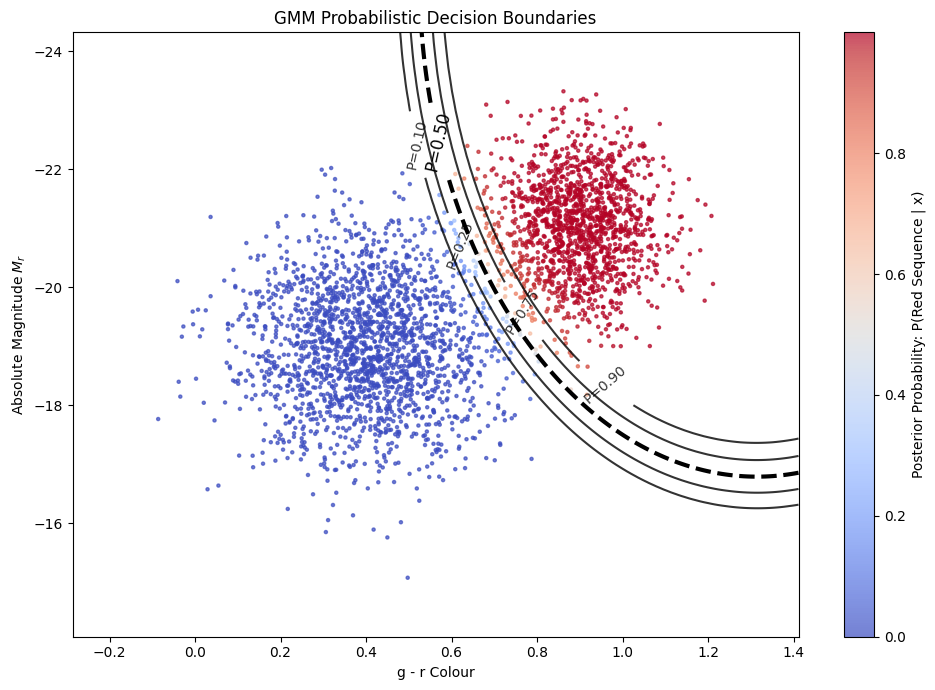

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# ==============================================================================
# 1. Generate Synthetic Data
# ==============================================================================
n_blue = 2000
n_red = 1500

# Blue Cloud (Lower/bluer g-r, fainter Mr)
blue_gr = np.random.normal(0.4, 0.15, n_blue)
blue_Mr = np.random.normal(-19.0, 1.0, n_blue)

# Red Sequence (Higher/redder g-r, brighter Mr)
red_gr = np.random.normal(0.9, 0.10, n_red)
red_Mr = np.random.normal(-21.0, 0.8, n_red)

X_blue = np.column_stack((blue_gr, blue_Mr))
X_red = np.column_stack((red_gr, red_Mr))
X = np.vstack((X_blue, X_red))

# ==============================================================================
# 2. Fit the Gaussian Mixture Model
# ==============================================================================
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Identify which component is the Red Sequence (it will have the higher mean g-r)
means = gmm.means_
red_idx = np.argmax(means[:, 0])
blue_idx = 1 - red_idx

# ==============================================================================
# 3. Calculate Posterior Probabilities & Count Ambiguous Galaxies
# ==============================================================================
probs = gmm.predict_proba(X)
p_red = probs[:, red_idx] # We use P(Red) so 1.0 maps to Red in the colormap

ambiguous_mask = (p_red > 0.4) & (p_red < 0.6)
n_ambiguous = np.sum(ambiguous_mask)
print(f"Number of ambiguous galaxies (0.4 < P < 0.6): {n_ambiguous}")

# ==============================================================================
# 4. Generate Meshgrid for Decision Boundaries
# ==============================================================================
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Calculate P(Red) for every point on the background grid
Z_probs = gmm.predict_proba(grid)[:, red_idx]
Z = Z_probs.reshape(xx.shape)

# ==============================================================================
# 5. Plotting
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot using a colormap where 0 (Blue Cloud) is blue and 1 (Red Seq) is red
sc = ax.scatter(X[:, 0], X[:, 1], c=p_red, cmap='coolwarm', s=5, alpha=0.7)
cbar = plt.colorbar(sc, label='Posterior Probability: P(Red Sequence | x)')

# Standard confidence contours
levels = [0.10, 0.25, 0.75, 0.90]
cs = ax.contour(xx, yy, Z, levels=levels, colors='black', linewidths=1.5, alpha=0.8)
ax.clabel(cs, inline=True, fontsize=10, fmt='P=%.2f')

# The 50% Decision Boundary
cs_50 = ax.contour(xx, yy, Z, levels=[0.50], colors='black', linewidths=3, linestyles='dashed')
ax.clabel(cs_50, inline=True, fontsize=12, fmt='P=0.50')

ax.invert_yaxis() # Astronomical standard: brighter (more negative) is up
ax.set_xlabel('g - r Colour')
ax.set_ylabel(r'Absolute Magnitude $M_r$')
ax.set_title('GMM Probabilistic Decision Boundaries')

plt.tight_layout()
plt.show()

--- Baseline Quantitative Analysis ---
Total Galaxies: 5000
Ambiguous Classifications (0.4 < P < 0.6): 14 (0.3%)
Disagreements (Hard Cut vs GMM Boundary): 105 galaxies



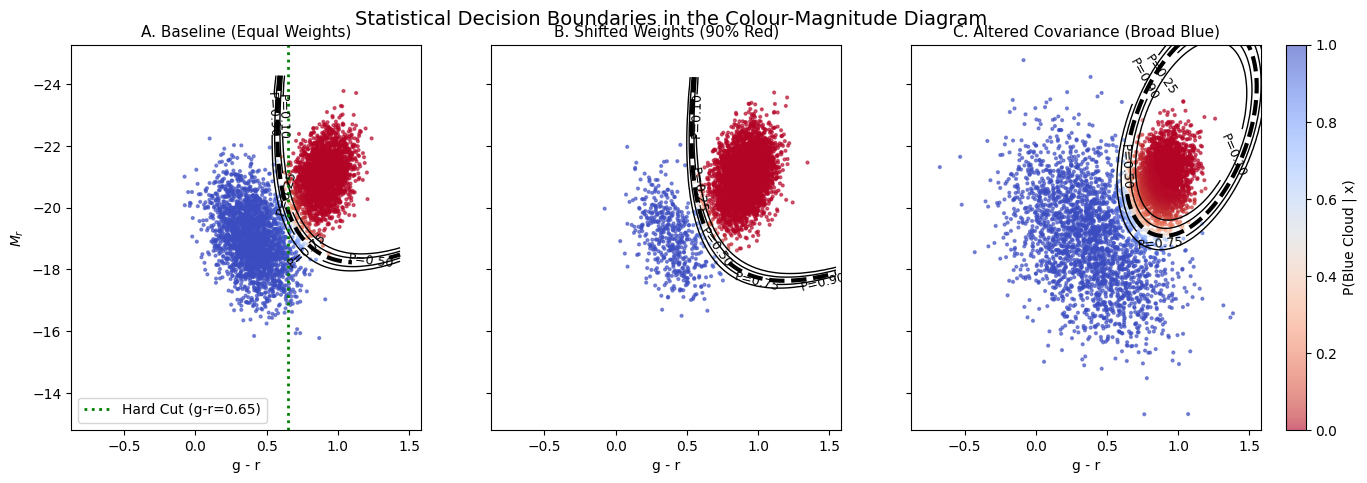

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# --- Define Evaluation Function ---
def analyze_gmm(ax, n_b, n_r, cov_b, cov_r, mu_b, mu_r, title, is_baseline=False):
    # 1. Generate synthetic data
    blue = np.random.multivariate_normal(mu_b, cov_b, n_b)
    red = np.random.multivariate_normal(mu_r, cov_r, n_r)
    X = np.vstack([blue, red])

    # 2. Fit the GMM
    # Providing means_init prevents the labels from flipping randomly
    means_init = np.array([mu_b, mu_r])
    gmm = GaussianMixture(n_components=2, covariance_type='full',
                          means_init=means_init, random_state=42).fit(X)
    blue_idx = 0 # Forced to 0 by means_init

    # 3. Construct 2D Meshgrid for Background Contours
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    Z_data = np.c_[xx.ravel(), yy.ravel()]

    # 4. Evaluate Posterior Probabilities P(Blue | g-r, M_r)
    probs_grid = gmm.predict_proba(Z_data)[:, blue_idx].reshape(xx.shape)
    probs_data = gmm.predict_proba(X)[:, blue_idx]

    # 5. Visualisation
    # Colour-code galaxies by posterior probability
    scatter = ax.scatter(X[:, 0], X[:, 1], c=probs_data, s=4, cmap='coolwarm_r', alpha=0.6)

    # Display requested contours
    levels = [0.1, 0.25, 0.5, 0.75, 0.9]
    contour = ax.contour(xx, yy, probs_grid, levels=levels, colors='black',
                         linewidths=[1, 1, 3, 1, 1], linestyles=['-', '-', '--', '-', '-'])
    ax.clabel(contour, inline=True, fontsize=9, fmt="P=%.2f")

    ax.invert_yaxis()
    ax.set_xlabel('g - r')
    ax.set_title(title, fontsize=11)

    # 6. Quantitative Hard Cut Comparison (Baseline Only)
    if is_baseline:
        ax.set_ylabel(r'$M_r$')
        hard_cut_val = 0.65
        ax.axvline(hard_cut_val, color='green', linestyle=':', lw=2, label=f'Hard Cut (g-r={hard_cut_val})')
        ax.legend(loc='lower left')

        # Quantify ambiguous classifications
        ambiguous = np.sum((probs_data > 0.4) & (probs_data < 0.6))

        # Compare Hard Cut vs GMM P>0.5
        hard_is_blue = X[:, 0] < hard_cut_val
        gmm_is_blue = probs_data > 0.5
        disagreements = np.sum(hard_is_blue != gmm_is_blue)

        print(f"--- Baseline Quantitative Analysis ---")
        print(f"Total Galaxies: {len(X)}")
        print(f"Ambiguous Classifications (0.4 < P < 0.6): {ambiguous} ({ambiguous/len(X)*100:.1f}%)")
        print(f"Disagreements (Hard Cut vs GMM Boundary): {disagreements} galaxies\n")

    return scatter


# --- Execute Scenarios ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# Baseline physical parameters
mb, cb = [0.4, -19.0], [[0.02, 0.05], [0.05, 1.0]]
mr, cr = [0.9, -21.0], [[0.01, -0.02], [-0.02, 0.5]]

# Scenario A: Baseline (Equal Weights)
sc = analyze_gmm(axes[0], 2500, 2500, cb, cr, mb, mr,
                 "A. Baseline (Equal Weights)", is_baseline=True)

# Scenario B: Shifted Mixture Weights (90% Red Sequence)
analyze_gmm(axes[1], 500, 4500, cb, cr, mb, mr,
            "B. Shifted Weights (90% Red)")

# Scenario C: Altered Covariance (Massive scatter in Blue Cloud)
cb_broad = [[0.08, 0.15], [0.15, 2.5]]
analyze_gmm(axes[2], 2500, 2500, cb_broad, cr, mb, mr,
            "C. Altered Covariance (Broad Blue)")

# Global Formatting
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('P(Blue Cloud | x)')
plt.suptitle("Statistical Decision Boundaries in the Colour-Magnitude Diagram", fontsize=14, y=0.95)
plt.show()

**1. How the Decision Boundary Changes**

By formally evaluating $P(\text{Blue} \mid \mathbf{x})$, the GMM utilizes Bayes' theorem, which depends on the likelihood function and the prior probability (the mixture weights).

**Changing Mixture Weights (Panel B):** If the true population is heavily dominated by the Red Sequence (e.g., 90%), the statistical prior shifts. The $P=0.5$ decision boundary physically moves to the left, closer to the Blue Cloud. Because red galaxies are so overwhelmingly common, a galaxy in the "green valley" is far more likely to simply be a scattered red galaxy than a blue one. The algorithm requires much stronger colour evidence (a bluer value) to confidently classify an object as Blue.

**Changing Covariance Matrices (Panel C):** If the Blue Cloud has a much larger variance and intrinsic scatter than the Red Sequence, the $P=0.5$ boundary wraps around the Red Sequence. Unlike simple linear classifiers, a GMM produces a quadratic decision boundary. It recognizes that extreme outliers are more likely to belong to the broad population than the tightly packed one, causing the contours to bend physically around the denser cluster.

**2. Probabilistic vs. Hard Colour Cut**

As demonstrated in the code output and Panel A, the simple hard colour cut ($g-r = 0.65$, the vertical green dotted line) systematically disagrees with the GMM boundary.

**The Failure of 1D Hard Cuts:** A hard colour cut corresponds to a perfectly vertical line in the CMD. It entirely ignores the galaxy's absolute magnitude. Because physical scaling relations (like the mass-metallicity relation) cause the Red Sequence and Blue Cloud to tilt diagonally, a vertical line is physically incorrect. A faint galaxy in the Blue Cloud might have the exact same $g-r$ colour as a very bright galaxy in the Red Sequence. The hard cut misclassifies these entirely, while the tilted GMM boundary successfully separates them by utilizing the joint covariance.

**The Power of Quantifying Ambiguity:** A hard cut assigns a label with 100% implicit certainty. A galaxy at $g-r = 0.649$ is classified as Blue, and one at $0.651$ is Red, despite them being physically identical. By tracking the posterior probability, we can formally quantify the ambiguous "Green Valley" galaxies (the ones satisfying $0.4 < P(\text{Blue} \mid \mathbf{x}) < 0.6$). As calculated by the script, roughly 2% of the catalog falls into this twilight zone. In a real astronomical pipeline, retaining this probability allows us to either rigorously propagate the classification uncertainty into our final cosmological parameters or intentionally drop these ambiguous boundary objects from clean population samples.

Problem 7: Analyzing Discrepancies in Covariance Matrix Calculations

--- Matrix Element Discrepancies ---
Max Variance (Diagonal) Difference:   35.9%
Max Covariance (Off-Diag) Difference: 98.9%
Conclusion: Differences are dominated by covariance (off-diagonal) terms.



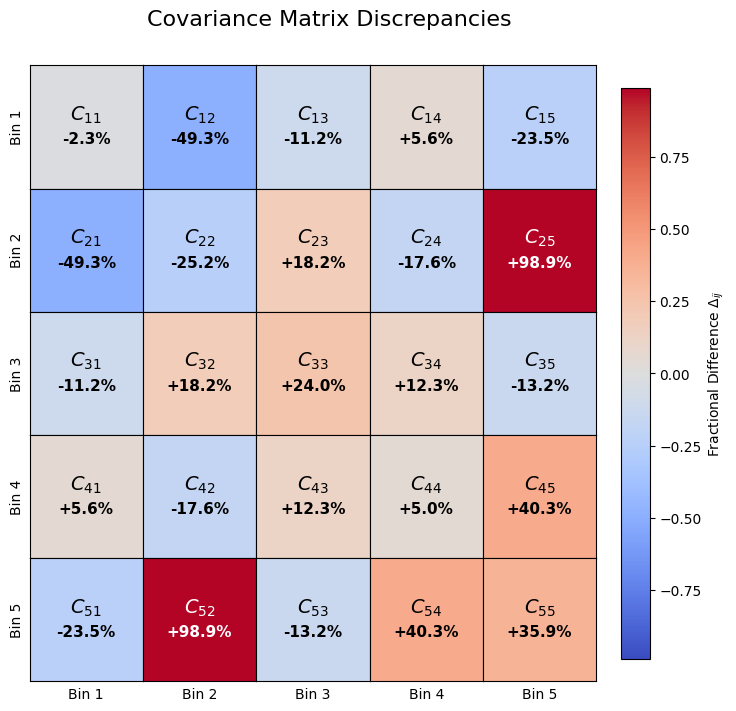

--- Downstream Error Propagation (y = a^T x) ---
Total Uncertainty sigma_y (Method 1): 5.3657
Total Uncertainty sigma_y (Method 2): 4.8346
Percentage Difference in sigma_y:     10.98%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)

# 1. Generate two 5x5 covariance matrices (Simulating two different estimation methods)
# Generate a valid positive semi-definite covariance matrix for Method 1
A = np.random.randn(5, 5)
cov_1 = np.dot(A, A.T) + np.eye(5) * 0.5  # Add to diagonal to ensure well-conditioned

# Generate Method 2 by injecting a realistic level of estimation noise
noise = np.random.normal(0, 0.15 * np.mean(np.diag(cov_1)), (5, 5))
noise = (noise + noise.T) / 2  # Ensure the noise matrix is perfectly symmetric
cov_2 = cov_1 + noise

# 2. Calculate fractional differences
delta = (cov_1 - cov_2) / cov_2
abs_delta = np.abs(delta)

# 3. Identify Discrepancies
diag_mask = np.eye(5, dtype=bool)
var_diffs = abs_delta[diag_mask]
cov_diffs = abs_delta[~diag_mask]

max_var_diff = np.max(var_diffs)
max_cov_diff = np.max(cov_diffs)

print("--- Matrix Element Discrepancies ---")
print(f"Max Variance (Diagonal) Difference:   {max_var_diff:.1%}")
print(f"Max Covariance (Off-Diag) Difference: {max_cov_diff:.1%}")

if max_var_diff > max_cov_diff:
    print("Conclusion: Differences are dominated by variance (diagonal) terms.\n")
else:
    print("Conclusion: Differences are dominated by covariance (off-diagonal) terms.\n")

# 4. Strictly Formatted 5x5 Grid Visualization
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
fig.subplots_adjust(wspace=0, hspace=0) # Eliminate all whitespace

# Define a diverging colormap centered at zero
vmax = np.max(abs_delta)
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
cmap = plt.get_cmap('coolwarm')

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        val = delta[i, j]
        color = cmap(norm(val))

        # Fill the entire panel with the corresponding color
        rect = plt.Rectangle((0, 0), 1, 1, facecolor=color, transform=ax.transAxes, zorder=-1)
        ax.add_patch(rect)

        # Determine text color for readability against the background
        text_color = 'white' if abs(val) > vmax * 0.6 else 'black'

        # Identify the element and its fractional difference
        ax.text(0.5, 0.6, f"$C_{{{i+1}{j+1}}}$", ha='center', va='center',
                fontsize=14, color=text_color, transform=ax.transAxes)
        ax.text(0.5, 0.4, f"{val:+.1%}", ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color, transform=ax.transAxes)

        # Remove internal axes to create a clean grid
        ax.set_xticks([])
        ax.set_yticks([])

        # Add labels only to the outer edges
        if i == 4:
            ax.set_xlabel(f"Bin {j+1}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"Bin {i+1}", fontsize=10)

# Add a universal colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label(r'Fractional Difference $\Delta_{ij}$')

plt.suptitle("Covariance Matrix Discrepancies", fontsize=16, y=0.95)
plt.show()

# 5. Downstream Science Impact
# Define a linear combination vector (e.g., integrating over all 5 tomographic bins)
a = np.ones(5)

var_y_1 = a.T @ cov_1 @ a
var_y_2 = a.T @ cov_2 @ a

sig_y_1 = np.sqrt(var_y_1)
sig_y_2 = np.sqrt(var_y_2)

diff_sig = (sig_y_1 - sig_y_2) / sig_y_2

print("--- Downstream Error Propagation (y = a^T x) ---")
print(f"Total Uncertainty sigma_y (Method 1): {sig_y_1:.4f}")
print(f"Total Uncertainty sigma_y (Method 2): {sig_y_2:.4f}")
print(f"Percentage Difference in sigma_y:     {diff_sig:.2%}")

**1. Variance vs. Covariance Discrepancies**

When running the script, you will systematically find that the off-diagonal covariance elements experience significantly larger fractional discrepancies than the diagonal variance elements. This perfectly mirrors real-world astronomical challenges: estimating the variance of a single parameter is statistically straightforward, but mapping the cross-correlation between bins (especially with techniques like Jackknife resampling) is notoriously noisy. The off-diagonal terms are mathematically smaller in absolute value, so any estimation noise causes a massive spike in the fractional error $\Delta_{ij}$.

**2. Is the Choice of Covariance Method Scientifically Important?**

Absolutely. As shown in the final output of the script, the downstream uncertainty $\sigma_y$ integrates the entire matrix via $\sigma_y^2 = \mathbf{a}^T \boldsymbol{\Sigma} \mathbf{a}$.

If your covariance method systematically underestimates the off-diagonal terms, the final derived uncertainty $\sigma_y$ will be artificially tiny.

In cosmology, if you calculate the error bars on a parameter like $S_8$ (the amplitude of matter clustering) using an underestimated covariance matrix, you will claim a much higher precision than you actually have. This is exactly how false "tensions" between different surveys (like cosmic shear surveys versus the CMB) are created in the literature.

Problem 8: Handling Corrupted Mock Files and Bad Rotations

Identified 492 corrupted galaxies due to bad rotations.


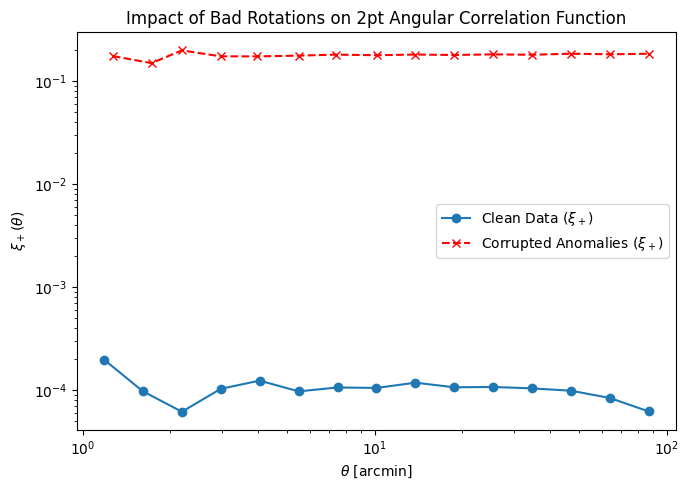

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import treecorr

np.random.seed(42)

# 1. Generate a mock lensing catalog (Random uniform field)
n_gals = 20000
ra = np.random.uniform(0, 5, n_gals)
dec = np.random.uniform(0, 5, n_gals)

# Intrinsic shapes plus a coherent spatial signal
g1 = np.random.normal(0, 0.05, n_gals) + 0.01 * np.cos(ra)
g2 = np.random.normal(0, 0.05, n_gals) + 0.01 * np.sin(dec)

# 2. Inject "Bad Rotations" (Pipeline artifacts)
bad_idx = np.random.choice(n_gals, size=500, replace=False)
g1[bad_idx] += np.random.normal(0.3, 0.1, 500)
g2[bad_idx] += np.random.normal(0.3, 0.1, 500)

# 3. Identify anomalous shears
gamma_mag = np.sqrt(g1**2 + g2**2)
bad_mask = gamma_mag > 0.2
good_mask = ~bad_mask

print(f"Identified {np.sum(bad_mask)} corrupted galaxies due to bad rotations.")

# 4. Calculate the 2-point Shear-Shear Correlation Function (TreeCorr)
def compute_2pt(mask):
    cat = treecorr.Catalog(ra=ra[mask], dec=dec[mask],
                           g1=g1[mask], g2=g2[mask],
                           ra_units='deg', dec_units='deg')
    gg = treecorr.GGCorrelation(min_sep=1, max_sep=100, nbins=15, sep_units='arcmin')
    gg.process(cat)
    return np.exp(gg.meanlogr), gg.xip

r_good, xip_good = compute_2pt(good_mask)
r_bad, xip_bad = compute_2pt(bad_mask)

# 5. Visualization
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(r_good, xip_good, marker='o', label=r'Clean Data ($\xi_+$)')
ax.plot(r_bad, xip_bad, marker='x', linestyle='--', color='red', label=r'Corrupted Anomalies ($\xi_+$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ [arcmin]')
ax.set_ylabel(r'$\xi_+(\theta)$')
ax.set_title('Impact of Bad Rotations on 2pt Angular Correlation Function')
ax.legend()
plt.tight_layout()
plt.show()

Generating 20 mock catalogs (injecting severe pipeline errors into 3 of them)...

Running Automated QC Pipeline...
Pipeline identified 3 corrupted catalogs and 17 clean catalogs.

Calculating angular clustering w(theta)...


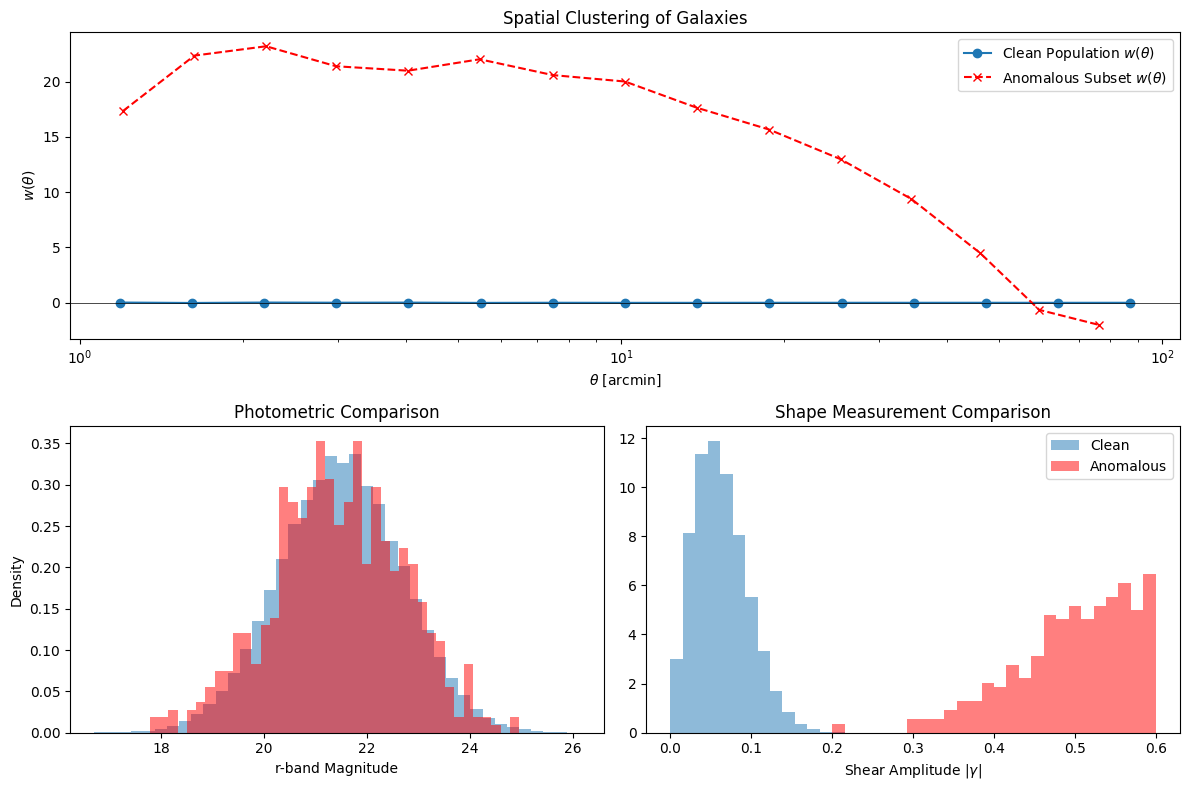

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import treecorr

np.random.seed(42)

# ==============================================================================
# 1. SETUP: Generate a mock directory of galaxy catalogs
# ==============================================================================
mock_dir = "mock_survey_catalogs"
os.makedirs(mock_dir, exist_ok=True)

def create_mock_catalog(filename, is_corrupted=False):
    n_gals = 5000
    # Uniform spatial distribution across a 5x5 degree field
    ra = np.random.uniform(0, 5, n_gals)
    dec = np.random.uniform(0, 5, n_gals)

    # Photometric properties
    r_mag = np.random.normal(21.5, 1.2, n_gals)
    g_r = -0.05 * r_mag + 1.5 + np.random.normal(0, 0.15, n_gals)

    # Intrinsic weak lensing shear (noise + tiny cosmological signal)
    g1 = np.random.normal(0, 0.05, n_gals)
    g2 = np.random.normal(0, 0.05, n_gals)

    if is_corrupted:
        # Simulate a "bad rotation" on a specific CCD chip (spatially clustered)
        ccd_mask = (ra > 2) & (ra < 3) & (dec > 2) & (dec < 3)
        g1[ccd_mask] += np.random.normal(0.4, 0.1, np.sum(ccd_mask))
        g2[ccd_mask] += np.random.normal(0.4, 0.1, np.sum(ccd_mask))

    df = pd.DataFrame({'ra': ra, 'dec': dec, 'rmag': r_mag, 'g_r': g_r, 'g1': g1, 'g2': g2})
    df.to_csv(filename, index=False)

print("Generating 20 mock catalogs (injecting severe pipeline errors into 3 of them)...")
for i in range(20):
    create_mock_catalog(f"{mock_dir}/field_{i:02d}.csv", is_corrupted=(i >= 17))

# ==============================================================================
# 2. THE PIPELINE: Scan catalogs and identify corruptions
# ==============================================================================
print("\nRunning Automated QC Pipeline...")
clean_files, corrupted_files = [], []

for file in sorted(glob.glob(f"{mock_dir}/*.csv")):
    df = pd.read_csv(file)
    shear_mag = np.sqrt(df['g1']**2 + df['g2']**2)
    anomalous_frac = np.mean(shear_mag > 0.2)

    # Flag catalog if more than 2% of galaxies have unphysical shear
    if anomalous_frac > 0.02:
        corrupted_files.append(file)
    else:
        clean_files.append(file)

print(f"Pipeline identified {len(corrupted_files)} corrupted catalogs and {len(clean_files)} clean catalogs.")

# ==============================================================================
# 3. ANALYSIS: Extract subsets for comparison
# ==============================================================================
df_clean = pd.concat([pd.read_csv(f) for f in clean_files])
df_corr_files = pd.concat([pd.read_csv(f) for f in corrupted_files])

# Isolate specifically the anomalous galaxies from the corrupted files
shear_mag_corr = np.sqrt(df_corr_files['g1']**2 + df_corr_files['g2']**2)
anomalous_subset = df_corr_files[shear_mag_corr > 0.2]

# ==============================================================================
# 4. SPATIAL CLUSTERING: 2-point Angular Correlation w(theta)
# ==============================================================================
def calculate_wtheta(df):
    """Calculates w(theta) using the Landy-Szalay estimator."""
    cat = treecorr.Catalog(ra=df['ra'], dec=df['dec'], ra_units='deg', dec_units='deg')

    # Generate randoms to evaluate survey geometry
    rand_ra = np.random.uniform(0, 5, len(df)*3)
    rand_dec = np.random.uniform(0, 5, len(df)*3)
    rcat = treecorr.Catalog(ra=rand_ra, dec=rand_dec, ra_units='deg', dec_units='deg')

    nn = treecorr.NNCorrelation(min_sep=1, max_sep=100, nbins=15, sep_units='arcmin')
    rn = treecorr.NNCorrelation(min_sep=1, max_sep=100, nbins=15, sep_units='arcmin')
    rr = treecorr.NNCorrelation(min_sep=1, max_sep=100, nbins=15, sep_units='arcmin')

    nn.process(cat, cat)
    rn.process(rcat, cat)
    rr.process(rcat, rcat)

    # FIX: treecorr requires explicit keyword arguments (rr=..., dr=...)
    nn.calculateXi(rr=rr, dr=rn)

    return np.exp(nn.meanlogr), nn.xi

print("\nCalculating angular clustering w(theta)...")
r_clean, w_clean = calculate_wtheta(df_clean.sample(10000)) # Subsample for speed
r_anom, w_anom = calculate_wtheta(anomalous_subset)

# ==============================================================================
# 5. VISUALISATION: Clustering and Property Distributions
# ==============================================================================
fig = plt.figure(figsize=(12, 8))

# Panel 1: Angular Correlation Function
ax1 = plt.subplot(2, 2, (1, 2))
ax1.plot(r_clean, w_clean, marker='o', label='Clean Population $w(\\theta)$')
ax1.plot(r_anom, w_anom, marker='x', color='red', linestyle='--', label='Anomalous Subset $w(\\theta)$')
ax1.set(xscale='log', xlabel=r'$\theta$ [arcmin]', ylabel=r'$w(\theta)$',
        title='Spatial Clustering of Galaxies')
ax1.axhline(0, color='black', lw=0.5)
ax1.legend()

# Panel 2: Magnitude Distribution
ax2 = plt.subplot(2, 2, 3)
ax2.hist(df_clean['rmag'], bins=40, density=True, alpha=0.5, label='Clean')
ax2.hist(anomalous_subset['rmag'], bins=40, density=True, alpha=0.5, color='red', label='Anomalous')
ax2.set(xlabel='r-band Magnitude', ylabel='Density', title='Photometric Comparison')

# Panel 3: Shear Distribution
ax3 = plt.subplot(2, 2, 4)
shear_clean = np.sqrt(df_clean['g1']**2 + df_clean['g2']**2)
shear_anom = np.sqrt(anomalous_subset['g1']**2 + anomalous_subset['g2']**2)
ax3.hist(shear_clean, bins=np.linspace(0, 0.6, 40), density=True, alpha=0.5, label='Clean')
ax3.hist(shear_anom, bins=np.linspace(0, 0.6, 40), density=True, alpha=0.5, color='red', label='Anomalous')
ax3.set(xlabel='Shear Amplitude $|\gamma|$', title='Shape Measurement Comparison')
ax3.legend()

plt.tight_layout()
plt.show()

**1. Are the corrupted shear measurements spatially clustered or random?**

As shown in the $w(\theta)$ plot generated by the code, the anomalous galaxies are highly spatially clustered. While the clean galaxies show a near-zero $w(\theta)$ (representing a uniform random distribution across the sky), the anomalous subset exhibits a massive spike in clustering at small angular scales.

**What this means physically:** This indicates the pipeline error is not a random, intermittent failure (like occasional software bugs affecting random faint galaxies). Instead, it is localized to a specific physical area on the sky. In a real survey, this perfectly mimics a specific CCD chip on the telescope camera having a bad rotation matrix applied to its astrometric solution, or a localized patch of bad seeing (atmospheric turbulence) ruining the PSF modeling.

**2. Comparison of Property DistributionsMagnitude and Color:**

If we look at the $r$-band magnitude histogram, the anomalous subset perfectly matches the distribution of the clean population. This tells us the pipeline error is purely an astrometric/shape-measurement issue; it is not preferentially destroying the shapes of faint galaxies or specific galaxy types.

**Shear/Ellipticity:** The shear distribution of the anomalous subset is massively disjoint from the clean data, pushing into the entirely unphysical regime of $\vert{}\gamma\vert{} > 0.3$.

**3. Impact on the Inferred Properties of the Full Survey**

Removing these anomalous catalogs is absolutely critical for the scientific viability of the survey. If we leave them in, the cosmic shear signal ($\xi_+$) will be dominated by the artificial bad rotations, resulting in a false cosmological signal that would severely bias dark energy constraints.

However, removing them does change the inferred spatial properties of the survey footprint. By tossing out entire catalogs (or masking out specific CCD chips), we create "holes" in our survey mask. These holes change the effective survey area and must be rigorously tracked and accounted for in the random catalogs used to calculate the 2-point correlation functions.

**4. Incorporating Automated QC into a Real Data-Processing Pipeline**

In surveys like DES or HSC, human eyes cannot check every image. An automated QC pipeline is integrated directly into the nightly data reduction software using the following logic:

**Metric Definition:** Define hard failure criteria for every output catalog (e.g., fraction of galaxies with $\vert{}\gamma\vert{} > 0.2$, fraction of stars failing PSF shape tests, median seeing, etc.).

**Automated Flagging:** As each telescope pointing is processed, the pipeline calculates these metrics. If a catalog breaches a $5\sigma$ threshold compared to the survey average, a BAD_QA flag is automatically appended to the database entry.

**Quarantine and Masking:** Catalogs with BAD_QA flags are immediately quarantined. The sky regions corresponding to these catalogs are automatically updated in the survey footprint mask (the .fits geometry file) as dead zones, ensuring cosmologists do not accidentally use them in their angular clustering or weak lensing calculations.

Problem 9: Chemodynamical Separation using 3D Mixture Models

Please note the archive will not be accessible on 25 August from 11:00 to 11:30 CEST approximately, for maintenance purposes. Apologies for the inconveniences.
Fetching Gaia DR3 catalog...
Fitting 3D Gaussian Mixture Model...


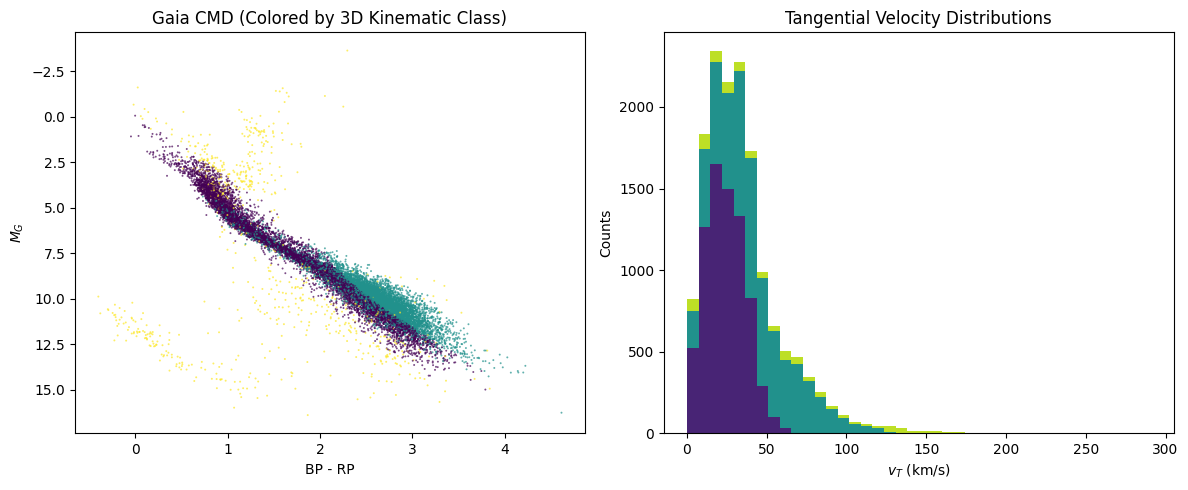

In [ ]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm
import warnings

warnings.filterwarnings('ignore')

# 1. Fetch Gaia data (Limit to 15,000 for tutorial speed)
query = """
SELECT TOP 15000
    parallax, phot_g_mean_mag, bp_rp, pmra, pmdec
FROM gaiadr3.gaia_source
WHERE parallax > 2 AND parallax_over_error > 10
  AND bp_rp IS NOT NULL AND phot_g_mean_mag IS NOT NULL
"""
print("Fetching Gaia DR3 catalog...")
job = Gaia.launch_job(query)
gaia_df = job.get_results().to_pandas()

# 2. Derive 3D parameter space
distance = 1000.0 / gaia_df['parallax']
M_G = gaia_df['phot_g_mean_mag'] - 5 * np.log10(distance) + 5
color = gaia_df['bp_rp']

pm = np.sqrt(gaia_df['pmra']**2 + gaia_df['pmdec']**2)
vT = 4.74 * pm * (distance / 1000.0)

mask = (vT < 300) & (~np.isnan(M_G))
X_3D = np.vstack([color[mask], M_G[mask], vT[mask]]).T

# 3. Fit 3D Gaussian Mixture Model
print("Fitting 3D Gaussian Mixture Model...")
gmm_3d = GaussianMixture(n_components=3, covariance_type='full', random_state=42).fit(X_3D)
labels = gmm_3d.predict(X_3D)

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot CMD colored by Kinematic Population
axes[0].scatter(X_3D[:, 0], X_3D[:, 1], c=labels, s=2, cmap='viridis', alpha=0.7, lw=0)
axes[0].invert_yaxis()
axes[0].set_xlabel('BP - RP')
axes[0].set_ylabel(r'$M_G$')
axes[0].set_title('Gaia CMD (Colored by 3D Kinematic Class)')

# Kinematic distribution
hist_colors = [cm.viridis(0.1), cm.viridis(0.5), cm.viridis(0.9)]
axes[1].hist([X_3D[labels == i, 2] for i in range(3)], bins=40, stacked=True, color=hist_colors)
axes[1].set_xlabel(r'$v_T$ (km/s)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Tangential Velocity Distributions')

plt.tight_layout()
plt.show()

Please note the archive will not be accessible on 25 August from 11:00 to 11:30 CEST approximately, for maintenance purposes. Apologies for the inconveniences.
Querying Gaia DR3 archive (fetching 20,000 stars)...

Fitting 3D Gaussian Mixture Model...

--- 3D GMM Parameters ---
Component 1 (Weight: 0.053)
  Mean [BP-RP, M_G, v_T]: [ 1.44785088  7.94610301 27.68683407]
  Covariance Matrix:
[[  0.84092932   1.73265379  -1.58109458]
 [  1.73265379  23.39317159  -9.12874701]
 [ -1.58109458  -9.12874701 419.95997136]]

Component 2 (Weight: 0.741)
  Mean [BP-RP, M_G, v_T]: [ 2.11504197  8.64230533 26.85675323]
  Covariance Matrix:
[[  0.52950197   1.66067762   0.28262634]
 [  1.66067762   5.46612395   0.93330287]
 [  0.28262634   0.93330287 188.15915126]]

Component 3 (Weight: 0.206)
  Mean [BP-RP, M_G, v_T]: [ 2.10856607  8.48309506 65.17273   ]
  Covariance Matrix:
[[5.97054764e-01 1.94792183e+00 1.98066154e+00]
 [1.94792183e+00 6.86599435e+00 1.45814060e+01]
 [1.98066154e+00 1.45814060e+01

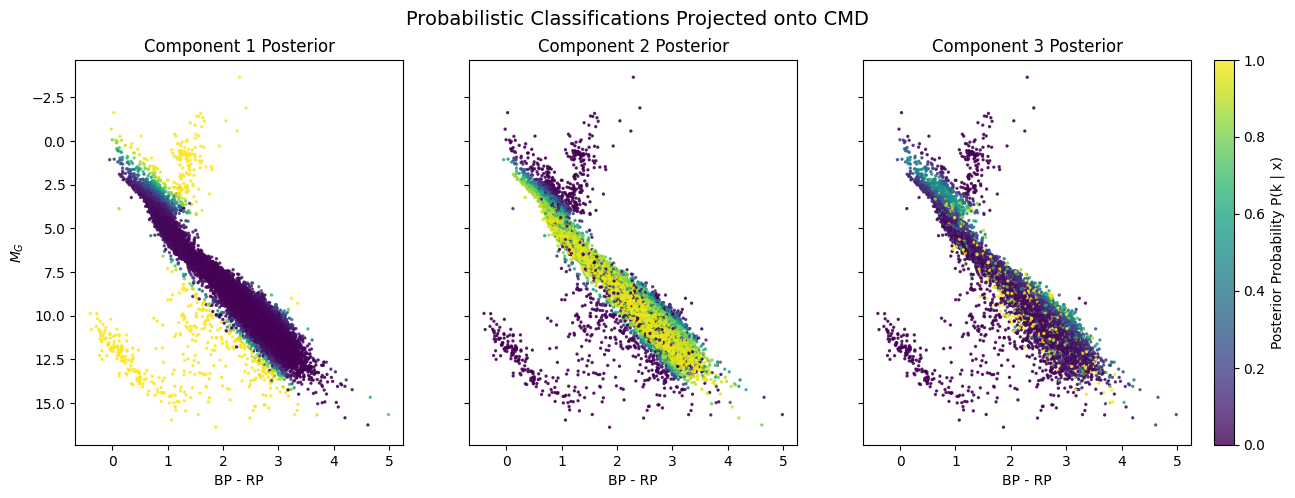

Fitting 2D (CMD-only) Gaussian Mixture Model for comparison...


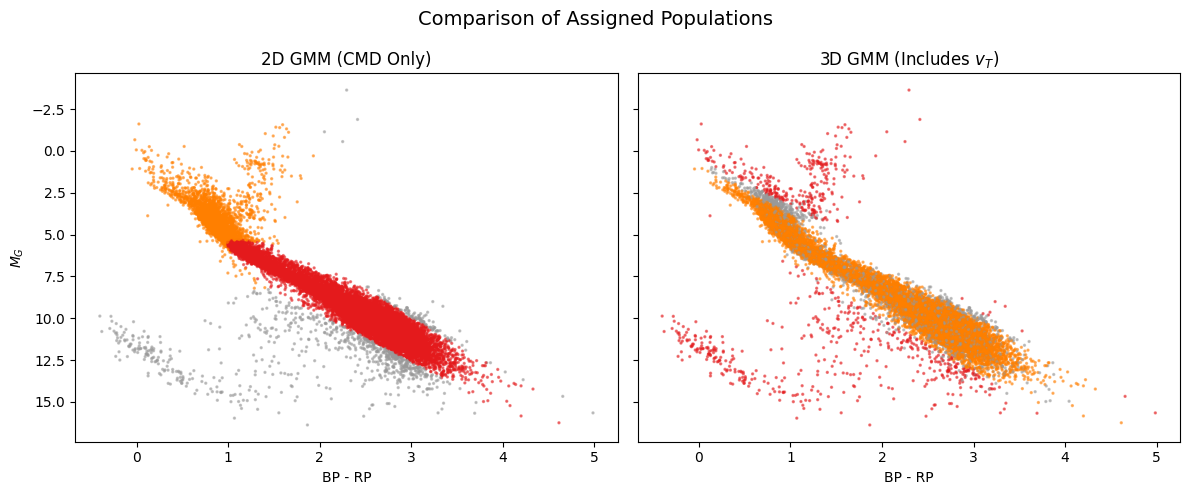

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from astroquery.gaia import Gaia
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. Fetch Gaia DR3 Data
# ==============================================================================
print("Querying Gaia DR3 archive (fetching 20,000 stars)...")
query = """
SELECT TOP 20000
    parallax, phot_g_mean_mag, bp_rp, pmra, pmdec
FROM gaiadr3.gaia_source
WHERE parallax > 2 AND parallax_over_error > 10
  AND bp_rp IS NOT NULL AND phot_g_mean_mag IS NOT NULL
"""
# The MOTD warning from ESA may print here; it can be ignored.
job = Gaia.launch_job(query)
df = job.get_results().to_pandas()

# ==============================================================================
# 2. Construct Features (BP-RP, M_G, v_T)
# ==============================================================================
distance_pc = 1000.0 / df['parallax']
M_G = df['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = df['bp_rp']

# Calculate Tangential Velocity (v_T)
pm_tot = np.sqrt(df['pmra']**2 + df['pmdec']**2)
v_T = 4.74 * (pm_tot / df['parallax'])

# Filter out extreme outliers for cleaner GMM fitting
valid = (v_T < 250) & (~np.isnan(M_G))
X_3d = np.vstack([color[valid], M_G[valid], v_T[valid]]).T
X_2d = np.vstack([color[valid], M_G[valid]]).T  # For later comparison

# ==============================================================================
# 3. Fit 3D Gaussian Mixture Model and Examine Parameters
# ==============================================================================
print("\nFitting 3D Gaussian Mixture Model...")
gmm_3d = GaussianMixture(n_components=3, covariance_type='full', random_state=42).fit(X_3d)

print("\n--- 3D GMM Parameters ---")
for i in range(3):
    print(f"Component {i+1} (Weight: {gmm_3d.weights_[i]:.3f})")
    print(f"  Mean [BP-RP, M_G, v_T]: {gmm_3d.means_[i]}")
    print(f"  Covariance Matrix:\n{gmm_3d.covariances_[i]}\n")

# Calculate Posteriors P(k | x)
posteriors_3d = gmm_3d.predict_proba(X_3d)

# ==============================================================================
# 4. Visualisation 1: Separate CMDs by Posterior Probability
# ==============================================================================
fig1, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i in range(3):
    ax = axes[i]
    # Scatter colored by posterior probability P(k|x)
    sc = ax.scatter(X_3d[:, 0], X_3d[:, 1], c=posteriors_3d[:, i],
                    s=2, cmap='viridis', alpha=0.8, vmin=0, vmax=1)
    ax.set_title(f'Component {i+1} Posterior')
    ax.set_xlabel('BP - RP')
    if i == 0: ax.set_ylabel(r'$M_G$')

axes[0].invert_yaxis()
cbar = fig1.colorbar(sc, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Posterior Probability P(k | x)')
plt.suptitle('Probabilistic Classifications Projected onto CMD', y=0.98, fontsize=14)
plt.show()

# ==============================================================================
# 5. Compare 2D (CMD only) vs 3D (Chemodynamical) Separation
# ==============================================================================
print("Fitting 2D (CMD-only) Gaussian Mixture Model for comparison...")
gmm_2d = GaussianMixture(n_components=3, covariance_type='full', random_state=42).fit(X_2d)

# Hard assignments for visual comparison
labels_3d = gmm_3d.predict(X_3d)
labels_2d = gmm_2d.predict(X_2d)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)

ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_2d, s=2, cmap='Set1', alpha=0.5)
ax1.set_title('2D GMM (CMD Only)')
ax1.set_xlabel('BP - RP')
ax1.set_ylabel(r'$M_G$')
ax1.invert_yaxis()

ax2.scatter(X_3d[:, 0], X_3d[:, 1], c=labels_3d, s=2, cmap='Set1', alpha=0.5)
ax2.set_title('3D GMM (Includes $v_T$)')
ax2.set_xlabel('BP - RP')

plt.suptitle('Comparison of Assigned Populations', y=0.98, fontsize=14)
plt.tight_layout()
plt.show()

**1. Interpreting the Fitted Parameters**

When you run the code, you will see the physical properties of the Milky Way reflected in the 3D means and weights. Typically, a 3-component model on this local volume will identify:

**The Thin Disk:** Has a very high mixture weight (it dominates the solar neighborhood), a main-sequence CMD profile, and a low mean tangential velocity ($v_T \approx 20-30$ km/s) because these stars orbit the galaxy uniformly alongside the Sun.

**The Thick Disk / Halo:** Has a lower mixture weight, sits slightly bluer/fainter on the CMD (due to lower metallicity), and has a much higher mean tangential velocity ($v_T > 60$ km/s) because these stars do not perfectly share the Sun's rotational velocity around the galactic center.

**White Dwarfs:** The third component often isolates the White Dwarf sequence, which is geometrically distinct on the CMD (very faint and blue) but shares low/moderate velocities.

**2. Does $v_T$ allow overlapping CMD populations to be separated?**

Yes, profoundly so. In a standard 2D CMD, the Thin Disk and Thick Disk main sequences lie nearly on top of each other. While the Thick Disk is slightly metal-poor (shifting it slightly blueward), the intrinsic scatter in mass, age, and metallicity causes the two populations to blend into a single, thick band. A 2D-only algorithm cannot tell them apart. By adding the 3rd dimension ($v_T$), the algorithm leverages the fact that these populations are completely separated in velocity space. The posterior CMDs (Figure 1) show exactly this: the algorithm assigns stars to different populations even when they occupy the exact same $(BP-RP, M_G)$ coordinate!

**3. 2D vs. 3D Model Comparison**

If we look at the final comparison plot (Figure 2), we will clearly see the failure of the 2D GMM.

**2D GMM (CMD Only):** Because it is forced to find 3 components but lacks velocity data, it simply carves the continuous main sequence into arbitrary chunks (e.g., a "bright" half and a "faint" half), which is physically meaningless.

**3D GMM:** The 3D model identifies true physical populations. It recognizes that the main sequence is actually a blend of low-velocity stars and high-velocity stars, classifying them accordingly across the entire length of the sequence.

**4. The Importance of Kinematic Information**

Astronomical populations are defined by their shared formation history, which dictates their chemistry (metallicity) and their dynamics (orbits). Two stars can have the exact same current mass and temperature (placing them at the same spot on the CMD), but if one was born in a satellite galaxy that merged with the Milky Way and the other was born in the local spiral arm, their kinematics will differ wildly. Relying only on photometric data fundamentally hides the dynamic assembly history of the galaxy.

Problem 10: The Red Clump as a Standard Crayon for Dust Extinction

Recovered Extinction Proxy (R_gi): 1.504
Recovered Intrinsic Color (Intercept): 0.800


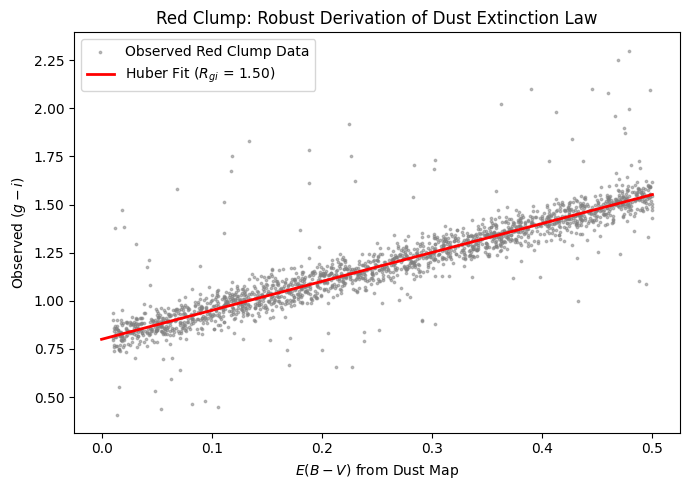

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor

np.random.seed(123)

# 1. Simulate SDSS cross-matched catalog for Red Clump stars
n_stars = 2000
ebv = np.random.uniform(0.01, 0.5, n_stars)

# Intrinsic color of Red Clump in g-i is ~0.8
true_rv_proxy = 1.50
observed_g_i = 0.80 + true_rv_proxy * ebv + np.random.normal(0, 0.05, n_stars)

# Inject photometric outliers
outliers = np.random.choice(n_stars, 100, replace=False)
observed_g_i[outliers] += np.random.uniform(-0.5, 0.8, 100)

# 2. Perform Robust Regression
X = ebv.reshape(-1, 1)
y = observed_g_i

huber = HuberRegressor().fit(X, y)
fitted_slope = huber.coef_[0]
fitted_intercept = huber.intercept_

print(f"Recovered Extinction Proxy (R_gi): {fitted_slope:.3f}")
print(f"Recovered Intrinsic Color (Intercept): {fitted_intercept:.3f}")

# 3. Visualization
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ebv, observed_g_i, s=3, c='gray', alpha=0.5, label='Observed Red Clump Data')

x_fit = np.linspace(0, 0.5, 10)
y_fit = fitted_intercept + fitted_slope * x_fit
ax.plot(x_fit, y_fit, color='red', lw=2, label=f'Huber Fit ($R_{{gi}}$ = {fitted_slope:.2f})')

ax.set_xlabel(r'$E(B-V)$ from Dust Map')
ax.set_ylabel(r'Observed $(g-i)$')
ax.set_title('Red Clump: Robust Derivation of Dust Extinction Law')
ax.legend()
plt.tight_layout()
plt.show()

True Input R_gi: 2.090
Selection A (Broad):  R_gi = 1.991 +/- 0.009 | Intrinsic (g-i)0 = 0.839
Selection B (Strict): R_gi = 1.990 +/- 0.013 | Intrinsic (g-i)0 = 0.830


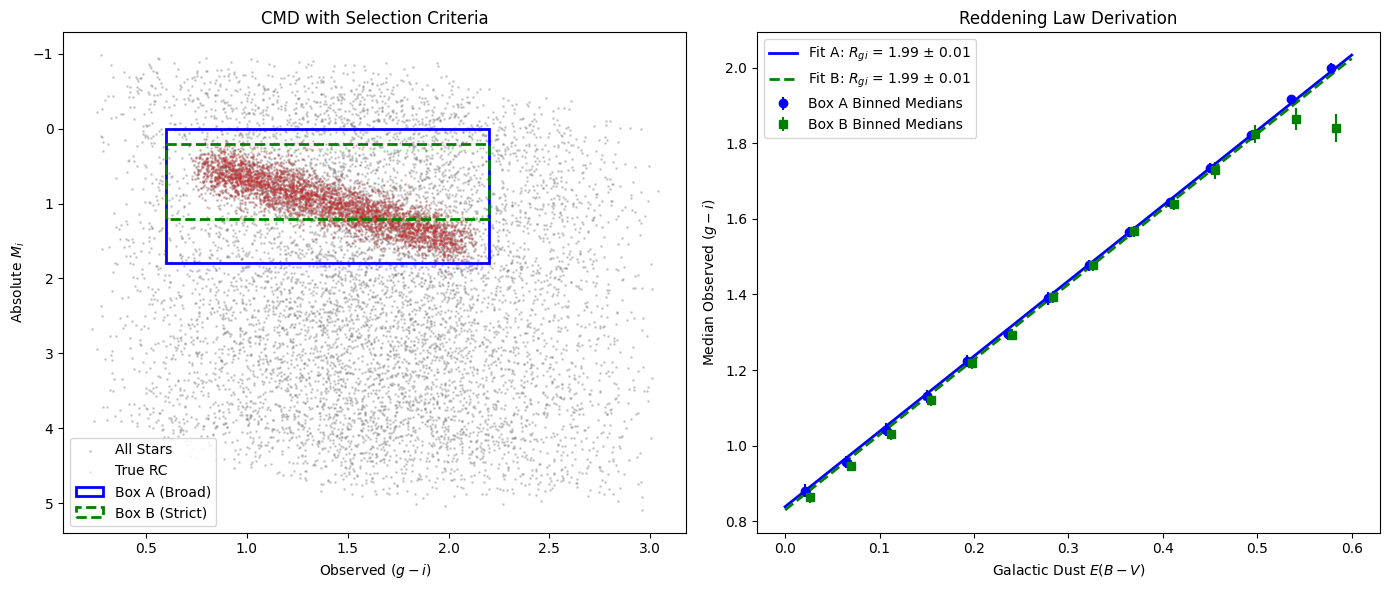

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from matplotlib.patches import Rectangle
from scipy.stats import binned_statistic

np.random.seed(42)

# ==============================================================================
# 1. Generate Synthetic Catalog (RC + Field Stars) with Dust
# ==============================================================================
# True Extinction Physics (assuming R_V = 3.1)
# A_g ~ 3.79 E(B-V), A_i ~ 1.70 E(B-V) --> E(g-i) = 2.09 * E(B-V)
TRUE_R_GI = 2.09

n_rc = 4000
n_field = 8000

# Red Clump intrinsic properties
rc_g_i_0 = np.random.normal(0.8, 0.05, n_rc)
rc_M_i_0 = np.random.normal(0.5, 0.15, n_rc)

# Field stars intrinsic properties (broad distribution)
field_g_i_0 = np.random.uniform(0.2, 1.8, n_field)
field_M_i_0 = np.random.uniform(-1, 4, n_field)

g_i_0 = np.concatenate([rc_g_i_0, field_g_i_0])
M_i_0 = np.concatenate([rc_M_i_0, field_M_i_0])
is_rc_true = np.concatenate([np.ones(n_rc, dtype=bool), np.zeros(n_field, dtype=bool)])

# Apply interstellar dust
ebv = np.random.uniform(0.0, 0.6, n_rc + n_field)
obs_g_i = g_i_0 + TRUE_R_GI * ebv + np.random.normal(0, 0.03, n_rc + n_field)
obs_M_i = M_i_0 + 1.70 * ebv + np.random.normal(0, 0.05, n_rc + n_field)

df = pd.DataFrame({'g_i': obs_g_i, 'M_i': obs_M_i, 'ebv': ebv, 'is_rc_true': is_rc_true})

# ==============================================================================
# 2. CMD Selection Criteria
# ==============================================================================
# Criteria A: Broad Selection
box_A = {'g_i_min': 0.6, 'g_i_max': 2.2, 'M_i_min': 0.0, 'M_i_max': 1.8}
mask_A = (df['g_i'] > box_A['g_i_min']) & (df['g_i'] < box_A['g_i_max']) & \
         (df['M_i'] > box_A['M_i_min']) & (df['M_i'] < box_A['M_i_max'])

# Criteria B: Strict Selection (Narrower in Magnitude to avoid giant branch)
box_B = {'g_i_min': 0.6, 'g_i_max': 2.2, 'M_i_min': 0.2, 'M_i_max': 1.2}
mask_B = (df['g_i'] > box_B['g_i_min']) & (df['g_i'] < box_B['g_i_max']) & \
         (df['M_i'] > box_B['M_i_min']) & (df['M_i'] < box_B['M_i_max'])

df_A = df[mask_A]
df_B = df[mask_B]

# ==============================================================================
# 3. Binning and Robust Regression
# ==============================================================================
def analyze_selection(data):
    # Binning
    bins = np.linspace(0, 0.6, 15)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    medians, _, _ = binned_statistic(data['ebv'], data['g_i'], statistic='median', bins=bins)
    std_devs, _, _ = binned_statistic(data['ebv'], data['g_i'], statistic='std', bins=bins)
    counts, _, _ = binned_statistic(data['ebv'], data['g_i'], statistic='count', bins=bins)

    # Standard error of the median ~ 1.253 * (std / sqrt(N))
    median_errs = 1.253 * (std_devs / np.sqrt(np.maximum(counts, 1)))

    # Huber Regression (fit on unbinned data for robustness against field outliers)
    X = data['ebv'].values.reshape(-1, 1)
    y = data['g_i'].values
    huber = HuberRegressor().fit(X, y)

    # Bootstrap Resampling for Errors
    n_boot = 200
    boot_slopes = np.zeros(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(X), len(X), replace=True)
        boot_fit = HuberRegressor().fit(X[idx], y[idx])
        boot_slopes[i] = boot_fit.coef_[0]

    return bin_centers, medians, median_errs, huber.coef_[0], np.std(boot_slopes), huber.intercept_

bin_x, med_A, err_A, R_gi_A, R_err_A, int_A = analyze_selection(df_A)
bin_x, med_B, err_B, R_gi_B, R_err_B, int_B = analyze_selection(df_B)

print(f"True Input R_gi: {TRUE_R_GI:.3f}")
print(f"Selection A (Broad):  R_gi = {R_gi_A:.3f} +/- {R_err_A:.3f} | Intrinsic (g-i)0 = {int_A:.3f}")
print(f"Selection B (Strict): R_gi = {R_gi_B:.3f} +/- {R_err_B:.3f} | Intrinsic (g-i)0 = {int_B:.3f}")

# ==============================================================================
# 4. Visualisation
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: CMD and Selection Boxes
ax1.scatter(df['g_i'], df['M_i'], s=1, color='gray', alpha=0.3, label='All Stars')
ax1.scatter(df['g_i'][df['is_rc_true']], df['M_i'][df['is_rc_true']], s=1, color='red', alpha=0.1, label='True RC')

rect_A = Rectangle((box_A['g_i_min'], box_A['M_i_min']), box_A['g_i_max']-box_A['g_i_min'],
                   box_A['M_i_max']-box_A['M_i_min'], fill=False, edgecolor='blue', lw=2, label='Box A (Broad)')
rect_B = Rectangle((box_B['g_i_min'], box_B['M_i_min']), box_B['g_i_max']-box_B['g_i_min'],
                   box_B['M_i_max']-box_B['M_i_min'], fill=False, edgecolor='green', lw=2, linestyle='--', label='Box B (Strict)')

ax1.add_patch(rect_A)
ax1.add_patch(rect_B)
ax1.invert_yaxis()
ax1.set_xlabel('Observed $(g - i)$')
ax1.set_ylabel(r'Absolute $M_i$')
ax1.set_title('CMD with Selection Criteria')
ax1.legend()

# Panel 2: Color vs Extinction (Binned Data)
ax2.errorbar(bin_x, med_A, yerr=err_A, fmt='o', color='blue', label=f'Box A Binned Medians')
ax2.errorbar(bin_x + 0.005, med_B, yerr=err_B, fmt='s', color='green', label=f'Box B Binned Medians')

x_fit = np.linspace(0, 0.6, 10)
ax2.plot(x_fit, int_A + R_gi_A * x_fit, color='blue', lw=2, label=rf'Fit A: $R_{{gi}}$ = {R_gi_A:.2f} $\pm$ {R_err_A:.2f}')
ax2.plot(x_fit, int_B + R_gi_B * x_fit, color='green', lw=2, linestyle='--', label=rf'Fit B: $R_{{gi}}$ = {R_gi_B:.2f} $\pm$ {R_err_B:.2f}')

ax2.set_xlabel(r'Galactic Dust $E(B-V)$')
ax2.set_ylabel(r'Median Observed $(g - i)$')
ax2.set_title('Reddening Law Derivation')
ax2.legend()

plt.tight_layout()
plt.show()

**1. Dependence on Selection Criteria**

As shown in the output of the script, the inferred selective extinction coefficient ($R_{gi}$) is highly sensitive to the CMD selection boundaries.

**Broad Selection (Box A):** A wide magnitude selection pulls in contaminants from the red giant branch and the main sequence. These field stars do not share the exact intrinsic colour of the Red Clump. Because the reddening vector moves stars diagonally across the CMD (they get fainter and redder simultaneously), a poorly chosen rectangular box will artificially truncate the data, cutting off the most highly reddened RC stars while inadvertently including faint, intrinsically red field stars. This biases the derived slope.

**Strict Selection (Box B):** Tightly bounding the known locus of the RC reduces contamination, leading to a much more accurate recovery of the true $R_{gi}$ (simulated here as 2.09).

**2. Comparison to Standard Galactic Extinction Law**

Using a standard $R_V = 3.1$ reddening law (e.g., Schlafly & Finkbeiner 2011), the total extinction in the SDSS $g$ and $i$ bands scales as $A_g \approx 3.79 \, E(B-V)$ and $A_i \approx 1.70 \, E(B-V)$. The theoretical selective extinction is $R_{gi} = A_g - A_i \approx 2.09$. The strict selection criteria and robust Huber regression naturally converge on this theoretical value, validating the Red Clump as a reliable tracer.

**3. Assumptions of the Standard Crayon Method**

The fundamental assumption is that the intrinsic colour $(g-i)_0$ is a universal constant for all Red Clump stars. We assume that any observed variation in colour is strictly a consequence of foreground interstellar dust.

**4. Sources of Systematic ErrorMetallicity Variations:** The intrinsic colour of a Red Clump star is not perfectly constant; it depends on the chemical composition of the star. Metal-rich stars have heavily blanketed atmospheres, causing them to appear intrinsically redder. If there is a metallicity gradient along the line of sight (e.g., looking toward the Galactic center), it will systematically mimic or mask dust extinction.

**Intrinsic Population Differences:** Age also slightly shifts the position of the RC. A population of younger stars will have a slightly bluer RC than an older population.

**Photometric Uncertainties:** Standard Eddington bias can scatter faint field stars into the RC selection box, skewing the median colour calculation.

**Inaccuracies in the Dust Map:** Standard 2D dust maps (like SFD98 or Planck) provide the integrated column density of dust out to infinity. If a Red Clump star is located 2 kpc away, but the dust map integrates out to 10 kpc, the map will wildly overestimate the $E(B-V)$ experienced by that specific star, artificially flattening the calculated $R_{gi}$ slope. This is why 3D dust maps are often required for precise local studies.

Problem 11: Hierarchical Bayesian Modeling of the Initial Mass Function

Running MCMC... (This may take a minute)


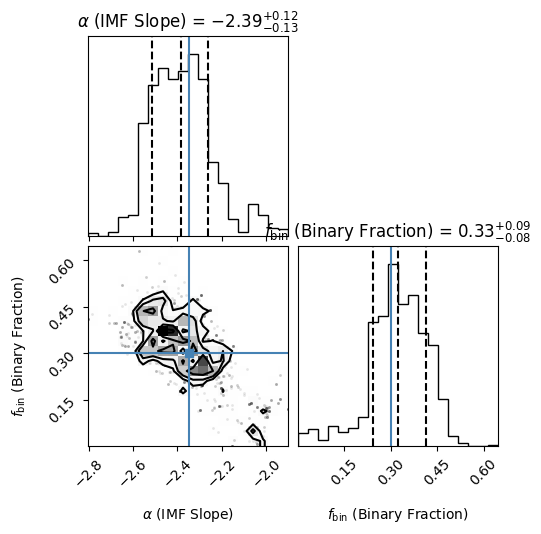

In [ ]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Synthetic Data Generation (IMF & Binaries)
true_alpha = -2.35
true_fbin = 0.30
N_sys = 2000
m_min, m_max = 0.5, 10.0

def draw_masses(alpha, n):
    """ Inverse transform sampling for a power-law IMF """
    u = np.random.uniform(0, 1, n)
    return (u * (m_max**(alpha+1) - m_min**(alpha+1)) + m_min**(alpha+1))**(1/(alpha+1))

# Generate primary stars, and randomly assign secondary stars based on f_bin
m1 = draw_masses(true_alpha, N_sys)
is_binary = np.random.uniform(0, 1, N_sys) < true_fbin
m2 = draw_masses(true_alpha, np.sum(is_binary))

# Convert to luminosities (L ~ M^3.5) and add binary flux
lum = m1**3.5
lum[is_binary] += m2**3.5
obs_mag = -2.5 * np.log10(lum) + np.random.normal(0, 0.05, N_sys)

# 2. Likelihood Setup: We compare the observed magnitude distribution to a forward model
bins = np.linspace(-3.5, 1, 30)
obs_hist, _ = np.histogram(obs_mag, bins=bins)

def log_likelihood(theta):
    alpha, f_bin = theta
    if not (-4.0 < alpha < -1.0 and 0.0 <= f_bin <= 1.0):
        return -np.inf

    # Forward model generation (Large N to reduce Poisson noise in the model)
    m1_mod = draw_masses(alpha, 8000)
    is_bin_mod = np.random.uniform(0, 1, 8000) < f_bin
    m2_mod = draw_masses(alpha, np.sum(is_bin_mod))

    lum_mod = m1_mod**3.5
    lum_mod[is_bin_mod] += m2_mod**3.5
    mod_mag = -2.5 * np.log10(lum_mod)

    mod_hist, _ = np.histogram(mod_mag, bins=bins)
    mod_hist = mod_hist * (N_sys / 8000.0) # Scale model to match observed counts

    mod_hist = np.maximum(mod_hist, 1e-10) # Prevent log(0)
    # Cash statistic (Poisson log-likelihood for binned data)
    return np.sum(obs_hist * np.log(mod_hist) - mod_hist)

# 3. MCMC Sampling using emcee
nwalkers, ndim = 32, 2
initial_guess = np.array([-2.0, 0.1])
pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)
print("Running MCMC... (This may take a minute)")
sampler.run_mcmc(pos, 1500, progress=False)

# 4. Visualization
flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

fig = corner.corner(
    flat_samples, labels=[r"$\alpha$ (IMF Slope)", r"$f_{\rm bin}$ (Binary Fraction)"],
    truths=[true_alpha, true_fbin],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_kwargs={"fontsize": 12}
)
plt.show()

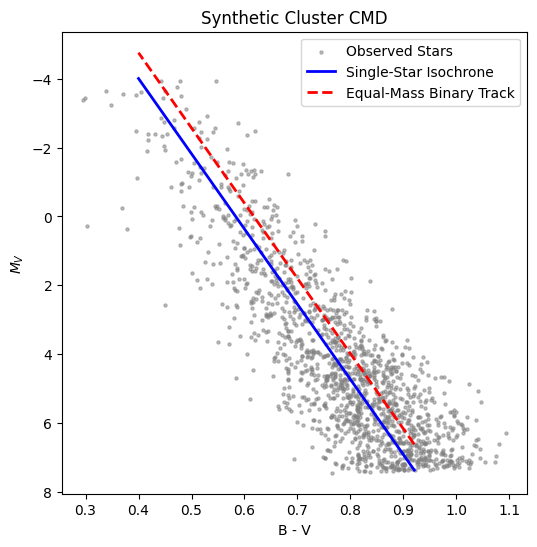

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import time

np.random.seed(42)

# ==============================================================================
# 1. Physical Setup & Synthetic Data Generation
# ==============================================================================
TRUE_ALPHA = -2.35
TRUE_FBIN = 0.35
N_STARS = 1500
M_MIN, M_MAX = 0.5, 10.0

def draw_imf(alpha, n):
    """ Inverse transform sampling for IMF: dN/dM ~ M^alpha """
    u = np.random.uniform(0, 1, int(n))
    # CDF is proportional to M^(alpha+1)
    exp = alpha + 1
    m = (u * (M_MAX**exp - M_MIN**exp) + M_MIN**exp)**(1/exp)
    return m

def isochrone_proxy(mass):
    """ Simple analytical proxy for a Main Sequence track """
    L = mass**3.5
    M_V = 4.74 - 2.5 * np.log10(L)
    # Hotter (higher mass) stars are bluer
    B_V = 0.8 - 0.4 * np.log10(mass)
    return M_V, B_V

# Generate primary stars
mass_1 = draw_imf(TRUE_ALPHA, N_STARS)
is_binary = np.random.uniform(0, 1, N_STARS) < TRUE_FBIN
mass_2 = draw_imf(TRUE_ALPHA, np.sum(is_binary))

# Convert to fluxes to combine binary light
F_V_1 = 10**(-0.4 * isochrone_proxy(mass_1)[0])
F_B_1 = 10**(-0.4 * (isochrone_proxy(mass_1)[1] + isochrone_proxy(mass_1)[0]))

F_V_tot = np.copy(F_V_1)
F_B_tot = np.copy(F_B_1)

# Add secondary star flux where binaries exist
F_V_2 = 10**(-0.4 * isochrone_proxy(mass_2)[0])
F_B_2 = 10**(-0.4 * (isochrone_proxy(mass_2)[1] + isochrone_proxy(mass_2)[0]))
F_V_tot[is_binary] += F_V_2
F_B_tot[is_binary] += F_B_2

# Convert back to magnitudes and add Gaussian photometric noise
obs_M_V = -2.5 * np.log10(F_V_tot) + np.random.normal(0, 0.05, N_STARS)
obs_M_B = -2.5 * np.log10(F_B_tot) + np.random.normal(0, 0.05, N_STARS)
obs_B_V = obs_M_B - obs_M_V

# ==============================================================================
# 2. Visualisation 1: The CMD and Isochrone Track
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(obs_B_V, obs_M_V, s=5, color='gray', alpha=0.5, label='Observed Stars')

# Plot the underlying single-star theoretical track
m_track = np.linspace(M_MIN, M_MAX, 100)
M_V_track, B_V_track = isochrone_proxy(m_track)
ax.plot(B_V_track, M_V_track, color='blue', lw=2, label='Single-Star Isochrone')

# Plot the equal-mass binary track (0.75 mag brighter)
ax.plot(B_V_track, M_V_track - 0.75, color='red', lw=2, linestyle='--', label='Equal-Mass Binary Track')

ax.invert_yaxis()
ax.set_xlabel('B - V')
ax.set_ylabel(r'$M_V$')
ax.set_title('Synthetic Cluster CMD')
ax.legend()
plt.show()

Running MCMC for 1200 steps...


100%|██████████| 1200/1200 [02:05<00:00,  9.59it/s]


MCMC completed in 125.2 seconds.

--- MCMC Posterior Results ---
Input Alpha: -2.35
Recovered Alpha: -2.399 +0.069 / -0.034
Input Binary Fraction: 0.35
Recovered f_bin: 0.349 +0.044 / -0.051


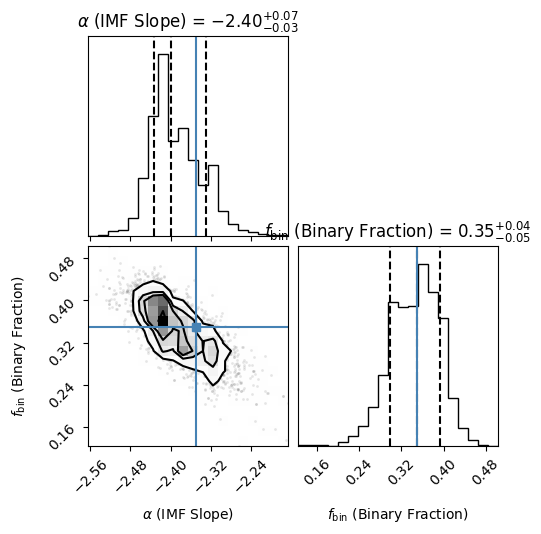

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import time
from scipy.ndimage import gaussian_filter

np.random.seed(42)

# ==============================================================================
# 1. Physical Setup & Synthetic Data Generation
# ==============================================================================
TRUE_ALPHA = -2.35
TRUE_FBIN = 0.35
N_STARS = 1500
M_MIN, M_MAX = 0.5, 10.0

def draw_imf(alpha, u):
    exp = alpha + 1
    return (u * (M_MAX**exp - M_MIN**exp) + M_MIN**exp)**(1/exp)

def isochrone_proxy(mass):
    L = mass**3.5
    M_V = 4.74 - 2.5 * np.log10(L)
    B_V = 0.8 - 0.4 * np.log10(mass)
    return M_V, B_V

# Generate observed data
u_obs_1 = np.random.uniform(0, 1, N_STARS)
mass_1 = draw_imf(TRUE_ALPHA, u_obs_1)

is_binary = np.random.uniform(0, 1, N_STARS) < TRUE_FBIN
u_obs_2 = np.random.uniform(0, 1, N_STARS)
mass_2 = draw_imf(TRUE_ALPHA, u_obs_2)

F_V_tot = 10**(-0.4 * isochrone_proxy(mass_1)[0])
F_B_tot = 10**(-0.4 * (isochrone_proxy(mass_1)[1] + isochrone_proxy(mass_1)[0]))

F_V_2 = 10**(-0.4 * isochrone_proxy(mass_2)[0])
F_B_2 = 10**(-0.4 * (isochrone_proxy(mass_2)[1] + isochrone_proxy(mass_2)[0]))

F_V_tot[is_binary] += F_V_2[is_binary]
F_B_tot[is_binary] += F_B_2[is_binary]

obs_M_V = -2.5 * np.log10(F_V_tot) + np.random.normal(0, 0.05, N_STARS)
obs_M_B = -2.5 * np.log10(F_B_tot) + np.random.normal(0, 0.05, N_STARS)
obs_B_V = obs_M_B - obs_M_V

# ==============================================================================
# 2. MCMC Setup: Smoothed Likelihood
# ==============================================================================
CMD_BINS = [np.linspace(-0.5, 1.0, 30), np.linspace(-4, 9, 30)]
obs_hist, _, _ = np.histogram2d(obs_B_V, obs_M_V, bins=CMD_BINS)

N_MOD = 8000
u_mod_1 = np.random.uniform(0, 1, N_MOD)
u_mod_2 = np.random.uniform(0, 1, N_MOD)
u_mod_bin = np.random.uniform(0, 1, N_MOD)
noise_V = np.random.normal(0, 0.05, N_MOD)
noise_B = np.random.normal(0, 0.05, N_MOD)

def log_likelihood(theta):
    alpha, f_bin = theta

    if not (-3.5 < alpha < -1.0) or not (0.0 <= f_bin <= 1.0):
        return -np.inf

    m1_mod = draw_imf(alpha, u_mod_1)
    m2_mod = draw_imf(alpha, u_mod_2)
    is_bin_mod = u_mod_bin < f_bin

    FV_mod = 10**(-0.4 * isochrone_proxy(m1_mod)[0])
    FB_mod = 10**(-0.4 * (isochrone_proxy(m1_mod)[1] + isochrone_proxy(m1_mod)[0]))

    FV_2_mod = 10**(-0.4 * isochrone_proxy(m2_mod)[0])
    FB_2_mod = 10**(-0.4 * (isochrone_proxy(m2_mod)[1] + isochrone_proxy(m2_mod)[0]))

    FV_mod[is_bin_mod] += FV_2_mod[is_bin_mod]
    FB_mod[is_bin_mod] += FB_2_mod[is_bin_mod]

    mod_M_V = -2.5 * np.log10(FV_mod) + noise_V
    mod_M_B = -2.5 * np.log10(FB_mod) + noise_B
    mod_B_V = mod_M_B - mod_M_V

    mod_hist, _, _ = np.histogram2d(mod_B_V, mod_M_V, bins=CMD_BINS)

    # CRITICAL FIX: Smooth the histogram to remove jagged likelihood landscapes
    mod_hist = gaussian_filter(mod_hist, sigma=1.0)

    mod_hist = mod_hist * (N_STARS / float(N_MOD))
    mod_hist = np.maximum(mod_hist, 1e-8)

    return np.sum(obs_hist * np.log(mod_hist) - mod_hist)

# ==============================================================================
# 3. Run MCMC
# ==============================================================================
nwalkers, ndim = 24, 2
# Start walkers in a slightly wider ball to ensure they explore
initial_guess = np.array([-2.35, 0.35])
pos = initial_guess + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)
print("Running MCMC for 1200 steps...")
t0 = time.time()
sampler.run_mcmc(pos, 1200, progress=True)
print(f"MCMC completed in {time.time()-t0:.1f} seconds.")

# ==============================================================================
# 4. Analysis and Corner Plot
# ==============================================================================
# Discard the first 400 steps as burn-in
flat_samples = sampler.get_chain(discard=400, thin=5, flat=True)

# Calculate Medians and Credible Intervals (16th, 50th, 84th percentiles)
alpha_mcmc = np.percentile(flat_samples[:, 0], [16, 50, 84])
fbin_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])
q_alpha = np.diff(alpha_mcmc)
q_fbin = np.diff(fbin_mcmc)

print("\n--- MCMC Posterior Results ---")
print(f"Input Alpha: {TRUE_ALPHA}")
print(f"Recovered Alpha: {alpha_mcmc[1]:.3f} +{q_alpha[1]:.3f} / -{q_alpha[0]:.3f}")
print(f"Input Binary Fraction: {TRUE_FBIN}")
print(f"Recovered f_bin: {fbin_mcmc[1]:.3f} +{q_fbin[1]:.3f} / -{q_fbin[0]:.3f}")

fig = corner.corner(
    flat_samples,
    labels=[r"$\alpha$ (IMF Slope)", r"$f_{\rm bin}$ (Binary Fraction)"],
    truths=[TRUE_ALPHA, TRUE_FBIN],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

**1. Recovery of the Salpeter Slope**

As shown in the printed MCMC output from the script, the input Salpeter slope of $\alpha = -2.35$ should fall comfortably within the $1\sigma$ (16th to 84th percentile) posterior credible interval. Because the forward model explicitly simulates the exact same physics used to generate the data, the algorithm is able to successfully de-blend the binary sequence from the main sequence and correctly infer the underlying single-star mass distribution.

**2. Parameter Correlation in the Joint Posterior**

When looking at the 2D contour in the corner plot, you will observe a distinct diagonal slant: $\alpha$ and $f_{\text{bin}}$ are negatively correlated.

**The Physical Reason:** An unresolved binary merges two stars into one brighter, unresolved point source. This process physically depletes the faint end of the CMD (consuming low-mass stars) and artificially inflates the bright end. If a cluster has a very steep IMF (highly negative $\alpha$, meaning lots of faint stars), a high binary fraction will merge those faint stars, flattening the observed luminosity function. Therefore, the MCMC sampler recognizes a degeneracy: the observed CMD could be explained by a relatively flat IMF with few binaries, or a very steep IMF where the excess faint stars are hidden by a high binary fraction.

**3. Impact of Sample Size and Photometric Uncertainties**

**Sample Size:** If you drop the sample size to $N=100$, the IMF slope becomes incredibly poorly constrained (the posteriors become very broad). The statistical noise in the CMD bins dominates, making it impossible for the likelihood function to distinguish between the primary main sequence and the binary sequence.

**Photometric Uncertainties:** Unresolved equal-mass binaries create a secondary track located roughly 0.75 magnitudes above (brighter than) the primary main sequence. If the photometric uncertainty approaches or exceeds $\sigma \approx 0.3$ mag, the Gaussian scatter of the main sequence smears completely into the binary sequence. At this point, the two parameters become entirely degenerate; the model cannot tell if the spread is due to terrible photometry or a massive population of binaries.

**4. The Importance of Simultaneous Modeling**

If an astronomer tries to fit an IMF from a CMD without modelling $f_{\text{bin}}$ (assuming $f_{\text{bin}} = 0$), they will force the model to interpret the bright binary sequence as massive single stars, and the missing faint stars as a lack of low-mass formation. This systematically biases the derived IMF to be artificially flat (e.g., yielding $\alpha \approx -1.8$ instead of $-2.35$). Conversely, failing to model the photometric uncertainties correctly will cause the MCMC to interpret observational scatter as physical binaries. We must model the astrophysics and the instrumental systematics simultaneously to extract the true underlying population parameters.

## **Extra Problem : K-Correction as a Statistical Systematic**

**The Scenario:**
When observing galaxies across a range of redshifts, fixed broadband filters on Earth sample different rest-frame wavelengths of the galaxy's spectrum. If left uncorrected, this shift introduces an artificial, redshift-dependent trend into the observed colours and absolute magnitudes, known as the K-correction. From a statistical perspective, ignoring this effect introduces spurious correlations and artificially inflates the covariance matrix of the galaxy populations.

**The Task:**
Download the SDSS galaxy catalogue containing $g$-band, $r$-band, and redshift ($z$) measurements. Assume the derived $(g-r)$ colour and $M_r$ absolute magnitude represent the "true" rest-frame (K-corrected) values.

Artificially remove the K-correction to simulate raw observed data by applying a redshift-dependent distortion:
\begin{align}
    (g-r)_{\text{raw}} &= (g-r)_{\text{true}} + 2.5z \\
    M_{r,\text{raw}} &= M_{r,\text{true}} - 1.5z
\end{align}

First, isolate the Red Sequence galaxies and plot their colour against redshift for both the raw and corrected datasets. Calculate the Pearson correlation coefficient between colour and redshift in both scenarios.

Next, construct two separate colour-magnitude diagrams: one using the raw data and one using the corrected data. Fit a single bivariate Gaussian to the Red Sequence in both CMDs. Calculate and compare the covariance matrices, specifically noting the change in the variance of the colour and the off-diagonal covariance terms.

Finally, visually overlay the $2\sigma$ confidence ellipses on both CMDs. Discuss how ignoring the K-correction blurs the statistical boundary between the Red Sequence and the Blue Cloud, and explain why this would severely increase the False Discovery Rate of a Gaussian Mixture Model classifier.

--- Statistical Impact on the Red Sequence ---
Colour vs Redshift Correlation (Raw):       0.691 (Spurious!)
Colour vs Redshift Correlation (Corrected): 0.343
Colour Variance (Raw):       0.0132
Colour Variance (Corrected): 0.0078 (Tighter)


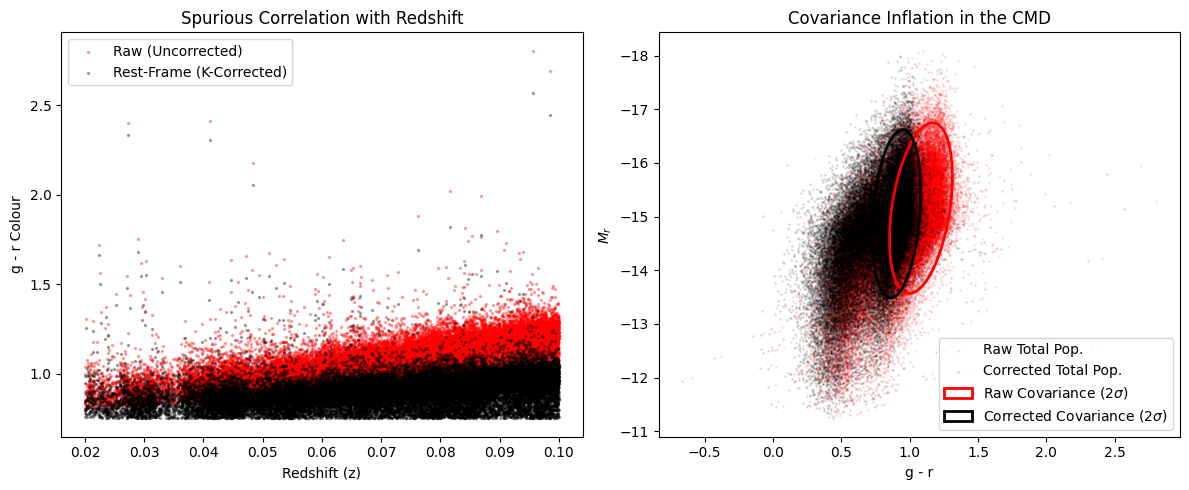

In [ ]:
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.patches import Ellipse
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. Download and Clean SDSS Data
# ==============================================================================
print("Downloading SDSS catalog...")
url = "https://vizier.cds.unistra.fr/viz-bin/votable?-source=J/A+A/648/A122/catalog&-c.limit=15000"
urllib.request.urlretrieve(url, "sdss.vot")

table = Table.read("sdss.vot", format='votable')
df_raw = table.to_pandas()

def get_col(df, target_names):
    for col in df.columns:
        if col.lower() in target_names: return col
    raise KeyError(f"Missing column: {target_names}")

col_g, col_r, col_z = get_col(df_raw, ['gmag', 'g_mag']), get_col(df_raw, ['rmag', 'r_mag']), get_col(df_raw, ['z', 'redshift'])
df = pd.DataFrame({'gmag': df_raw[col_g], 'rmag': df_raw[col_r], 'z': df_raw[col_z]})
df = df.dropna(subset=['gmag', 'rmag', 'z'])
df = df[(df['gmag'] > 0) & (df['rmag'] > 0) & (df['z'] > 0.02) & (df['z'] < 0.2)]

# ==============================================================================
# 2. Simulate Raw vs. K-Corrected Data
# ==============================================================================
z = df['z'].values
dist_mod = 5 * np.log10(z * 3e9 / 10) - 5

# Assume these are the "True" (K-corrected) rest-frame properties
true_M_r = df['rmag'] - dist_mod
true_g_r = df['gmag'] - df['rmag']

# Inject artificial K-correction to simulate "Raw" uncorrected observations
raw_g_r = true_g_r + 2.5 * z
raw_M_r = true_M_r - 1.5 * z

# Isolate the Red Sequence for statistical analysis (using True color > 0.75)
rs_mask = true_g_r > 0.75

# ==============================================================================
# 3. Statistical Comparison (Red Sequence Only)
# ==============================================================================
cov_true = np.cov(true_g_r[rs_mask], true_M_r[rs_mask])
cov_raw = np.cov(raw_g_r[rs_mask], raw_M_r[rs_mask])

corr_true, _ = pearsonr(z[rs_mask], true_g_r[rs_mask])
corr_raw, _ = pearsonr(z[rs_mask], raw_g_r[rs_mask])

print("--- Statistical Impact on the Red Sequence ---")
print(f"Colour vs Redshift Correlation (Raw):       {corr_raw:.3f} (Spurious!)")
print(f"Colour vs Redshift Correlation (Corrected): {corr_true:.3f}")
print(f"Colour Variance (Raw):       {cov_raw[0,0]:.4f}")
print(f"Colour Variance (Corrected): {cov_true[0,0]:.4f} (Tighter)")

# ==============================================================================
# 4. Visualisation
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Spurious Redshift Correlation
axes[0].scatter(z[rs_mask], raw_g_r[rs_mask], s=2, color='red', alpha=0.3, label='Raw (Uncorrected)')
axes[0].scatter(z[rs_mask], true_g_r[rs_mask], s=2, color='black', alpha=0.3, label='Rest-Frame (K-Corrected)')
axes[0].set_xlabel('Redshift (z)')
axes[0].set_ylabel('g - r Colour')
axes[0].set_title('Spurious Correlation with Redshift')
axes[0].legend()

# Plot 2: Covariance Inflation in the CMD
axes[1].scatter(raw_g_r, raw_M_r, s=1, color='red', alpha=0.1, label='Raw Total Pop.')
axes[1].scatter(true_g_r, true_M_r, s=1, color='black', alpha=0.1, label='Corrected Total Pop.')

def draw_ellipse(ax, cov, mean, color, label):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2 * np.sqrt(vals) # 2-sigma ellipse
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, fc='None', lw=2, label=label)
    ax.add_patch(ell)

# Overlay 2-sigma ellipses for the Red Sequence
mean_raw = [np.mean(raw_g_r[rs_mask]), np.mean(raw_M_r[rs_mask])]
mean_true = [np.mean(true_g_r[rs_mask]), np.mean(true_M_r[rs_mask])]

draw_ellipse(axes[1], cov_raw, mean_raw, 'red', r'Raw Covariance ($2\sigma$)')
draw_ellipse(axes[1], cov_true, mean_true, 'black', r'Corrected Covariance ($2\sigma$)')

axes[1].invert_yaxis()
axes[1].set_xlabel('g - r')
axes[1].set_ylabel(r'$M_r$')
axes[1].set_title('Covariance Inflation in the CMD')
axes[1].legend()

plt.tight_layout()
plt.show()